In [1]:
мец патмуцюн покрик кахакум


from dotenv import load_dotenv
import os
import clickhouse_connect
import pandas as pd

# Загружаем .env
load_dotenv(".env")

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST")
CLICKHOUSE_PORT = int(os.getenv("CLICKHOUSE_PORT", "8123"))
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "polyk")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD")

c = clickhouse_connect.get_client(
    host=CLICKHOUSE_HOST,
    port=CLICKHOUSE_PORT,
    username=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB,
)

print("Connected to:", CLICKHOUSE_DB)

SyntaxError: invalid syntax (1655288909.py, line 1)

In [2]:


from dotenv import load_dotenv
import os
import clickhouse_connect
import pandas as pd

# Загружаем .env
load_dotenv(".env")

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST")
CLICKHOUSE_PORT = int(os.getenv("CLICKHOUSE_PORT", "8123"))
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "polyk")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD")

c = clickhouse_connect.get_client(
    host=CLICKHOUSE_HOST,
    port=CLICKHOUSE_PORT,
    username=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB,
)

print("Connected to:", CLICKHOUSE_DB)

Connected to: polyk


In [3]:
q = "SELECT * FROM polyk.pm_top_of_book ORDER BY event_ts_ms DESC LIMIT 20"
res = client.query(q)
import pandas as pd
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


NameError: name 'client' is not defined

In [4]:
q = "SELECT * FROM polyk.pm_top_of_book ORDER BY event_ts_ms DESC LIMIT 20"
res = c.query(q)
import pandas as pd
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


,ingest_time,market,event_ts_ms,asset_id,outcome,best_bid_price,best_bid_size,best_ask_price,best_ask_size,source
0,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100661018,1019296209389274395304303501832959150233627133...,UP,0.61,121.74,0.63,1124.00,orderbook
1,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,74.23,orderbook
2,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2879903950077237607002215362357017698383898408...,DOWN,0.38,74.23,0.39,38.00,orderbook
3,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2879903950077237607002215362357017698383898408...,DOWN,0.38,76.98,0.39,38.00,orderbook
4,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,76.98,orderbook
5,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660695,2879903950077237607002215362357017698383898408...,DOWN,0.38,71.98,0.39,48.00,orderbook
6,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660695,1019296209389274395304303501832959150233627133...,UP,0.61,48.00,0.62,71.98,orderbook
7,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660688,2879903950077237607002215362357017698383898408...,DOWN,0.38,71.98,0.39,53.00,orderbook
8,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660688,1019296209389274395304303501832959150233627133...,UP,0.61,53.00,0.62,71.98,orderbook
9,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660519,2879903950077237607002215362357017698383898408...,DOWN,0.38,102.98,0.39,60.48,orderbook


In [5]:
c.command("SET asterisk_include_materialized_columns = 1")


DatabaseError: HTTP driver received HTTP status 404, server response: Code: 115, e.displayText() = DB::Exception: Unknown setting asterisk_include_materialized_columns, e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [6]:
c = clickhouse_connect.get_client(..., settings={"asterisk_include_materialized_columns": 1})


TypeError: create_client() takes 0 positional arguments but 1 positional argument (and 1 keyword-only argument) were given

In [7]:
c.query("DESCRIBE TABLE polyk.pm_top_of_book").result_rows


[('ingest_time', 'DateTime', '', '', ''),
 ('market', 'String', '', '', ''),
 ('event_ts_ms', 'UInt64', '', '', ''),
 ('asset_id', 'String', '', '', ''),
 ('outcome', 'String', '', '', ''),
 ('best_bid_price', 'Float64', '', '', ''),
 ('best_bid_size', 'Float64', '', '', ''),
 ('best_ask_price', 'Float64', '', '', ''),
 ('best_ask_size', 'Float64', '', '', ''),
 ('source', 'String', '', '', ''),
 ('event_time_msk',
  'DateTime',
  'MATERIALIZED',
  "toTimeZone(toDateTime(event_ts_ms / 1000), 'Europe/Moscow')",
  '')]

In [8]:
q = """
SELECT ingest_time, market, event_ts_ms, event_time_msk, asset_id, outcome,
       best_bid_price, best_bid_size, best_ask_price, best_ask_size, source
FROM polyk.pm_top_of_book
ORDER BY event_ts_ms DESC
LIMIT 20
"""
res = c.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df





,ingest_time,market,event_ts_ms,event_time_msk,asset_id,outcome,best_bid_price,best_bid_size,best_ask_price,best_ask_size,source
0,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100661018,2026-02-14 20:24:21,1019296209389274395304303501832959150233627133...,UP,0.61,121.74,0.63,1124.00,orderbook
1,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,74.23,orderbook
2,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,74.23,0.39,38.00,orderbook
3,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,76.98,0.39,38.00,orderbook
4,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,76.98,orderbook
5,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660695,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,71.98,0.39,48.00,orderbook
6,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660695,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,48.00,0.62,71.98,orderbook
7,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660688,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,71.98,0.39,53.00,orderbook
8,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660688,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,53.00,0.62,71.98,orderbook
9,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660519,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,102.98,0.39,60.48,orderbook


In [9]:
df

,ingest_time,market,event_ts_ms,event_time_msk,asset_id,outcome,best_bid_price,best_bid_size,best_ask_price,best_ask_size,source
0,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100661018,2026-02-14 20:24:21,1019296209389274395304303501832959150233627133...,UP,0.61,121.74,0.63,1124.00,orderbook
1,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,74.23,orderbook
2,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,74.23,0.39,38.00,orderbook
3,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,76.98,0.39,38.00,orderbook
4,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,76.98,orderbook
5,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660695,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,71.98,0.39,48.00,orderbook
6,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660695,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,48.00,0.62,71.98,orderbook
7,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660688,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,71.98,0.39,53.00,orderbook
8,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660688,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,53.00,0.62,71.98,orderbook
9,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660519,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,102.98,0.39,60.48,orderbook


In [10]:
q = """
SELECT ingest_time, market, event_ts_ms, event_time_msk, asset_id, outcome,
       best_bid_price, best_bid_size, best_ask_price, best_ask_size, source
FROM polyk.pm_top_of_book
ORDER BY event_ts_ms DESC
LIMIT 200
"""
res = c.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


,ingest_time,market,event_ts_ms,event_time_msk,asset_id,outcome,best_bid_price,best_bid_size,best_ask_price,best_ask_size,source
0,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100661018,2026-02-14 20:24:21,1019296209389274395304303501832959150233627133...,UP,0.61,121.74,0.63,1124.00,orderbook
1,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,74.23,0.39,38.00,orderbook
2,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660853,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,74.23,orderbook
3,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2026-02-14 20:24:20,2879903950077237607002215362357017698383898408...,DOWN,0.38,76.98,0.39,38.00,orderbook
4,2026-02-14 20:24:52,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100660841,2026-02-14 20:24:20,1019296209389274395304303501832959150233627133...,UP,0.61,38.00,0.62,76.98,orderbook
...,...,...,...,...,...,...,...,...,...,...,...
195,2026-02-14 20:24:03,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100598392,2026-02-14 20:23:18,2879903950077237607002215362357017698383898408...,DOWN,0.29,270.24,0.30,158.00,orderbook
196,2026-02-14 20:24:03,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100598392,2026-02-14 20:23:18,1019296209389274395304303501832959150233627133...,UP,0.70,158.00,0.71,270.24,orderbook
197,2026-02-14 20:24:03,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100598359,2026-02-14 20:23:18,1019296209389274395304303501832959150233627133...,UP,0.70,114.00,0.71,270.24,orderbook
198,2026-02-14 20:24:03,0xea3f69d9a3123f617d08cd3ea51f0b25f9d1552c949e...,1771100598359,2026-02-14 20:23:18,2879903950077237607002215362357017698383898408...,DOWN,0.29,270.24,0.30,114.00,orderbook


In [1]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT market, trade_price_up, model_prob_up, sigma, abs_edge, ingest_time
FROM polyk.pm_mispricing_events
ORDER BY ingest_time DESC
LIMIT 20
""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


DatabaseError: HTTP driver received HTTP status 400, server response: Code: 62, e.displayText() = DB::Exception: Syntax error (Multi-statements are not allowed): failed at position 67 (end of query) (line 2, col 66): ;


 FORMAT Native. , e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [2]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  market,
  trade_price_up,
  best_bid_price,
  best_ask_price,
  model_prob_up,
  abs_edge
FROM polyk.pm_mispricing_events
ORDER BY ingest_time DESC
LIMIT 20

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


,market,trade_price_up,model_prob_up,sigma,abs_edge,ingest_time
0,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.65,0.499160,0.991342,0.150840,2026-02-16 16:00:48+03:00
1,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.58,0.499160,0.991342,0.080840,2026-02-16 16:00:48+03:00
2,0xf6b3bebf2e3c8fd3ab919a8d311bb3532d4784f28f8a...,0.32,0.498533,1.404312,0.178533,2026-02-16 16:00:48+03:00
3,0x4fde5a2d8a6f42a11df822766030ea33e6e0b013c533...,0.30,0.495046,1.404312,0.195046,2026-02-16 16:00:48+03:00
4,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.66,0.499160,0.991342,0.160840,2026-02-16 16:00:48+03:00
5,0xf6b3bebf2e3c8fd3ab919a8d311bb3532d4784f28f8a...,0.31,0.498533,1.404312,0.188533,2026-02-16 16:00:48+03:00
6,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.64,0.499160,0.991342,0.140840,2026-02-16 16:00:48+03:00
7,0x4fde5a2d8a6f42a11df822766030ea33e6e0b013c533...,0.27,0.495046,1.404312,0.225046,2026-02-16 16:00:48+03:00
8,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.66,0.499160,0.991342,0.160840,2026-02-16 16:00:48+03:00
9,0xf6b3bebf2e3c8fd3ab919a8d311bb3532d4784f28f8a...,0.32,0.498533,1.404312,0.178533,2026-02-16 16:00:48+03:00


In [3]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  market,
  trade_price_up,
  best_bid_price,
  best_ask_price,
  model_prob_up,
  abs_edge
FROM polyk.pm_mispricing_events
ORDER BY ingest_time DESC
LIMIT 20

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


,market,trade_price_up,best_bid_price,best_ask_price,model_prob_up,abs_edge
0,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.65,0.73,0.74,0.499160,0.150840
1,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.58,0.73,0.74,0.499160,0.080840
2,0xf6b3bebf2e3c8fd3ab919a8d311bb3532d4784f28f8a...,0.32,0.35,0.36,0.498533,0.178533
3,0x4fde5a2d8a6f42a11df822766030ea33e6e0b013c533...,0.30,0.50,0.51,0.495046,0.195046
4,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.66,0.73,0.74,0.499160,0.160840
5,0xf6b3bebf2e3c8fd3ab919a8d311bb3532d4784f28f8a...,0.31,0.35,0.36,0.498533,0.188533
6,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.64,0.73,0.74,0.499160,0.140840
7,0x4fde5a2d8a6f42a11df822766030ea33e6e0b013c533...,0.27,0.50,0.51,0.495046,0.225046
8,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.66,0.73,0.74,0.499160,0.160840
9,0xf6b3bebf2e3c8fd3ab919a8d311bb3532d4784f28f8a...,0.32,0.35,0.36,0.498533,0.178533


In [4]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  market,
  trade_price_up,
  best_bid_price,
  best_ask_price,
  model_prob_up,
  abs_edge
FROM polyk.pm_mispricing_events
ORDER BY ingest_time DESC
LIMIT 20

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


DatabaseError: HTTP driver received HTTP status 404, server response: Code: 47, e.displayText() = DB::Exception: Unknown identifier: trade_price_up, e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [5]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  market,
  trade_price_up,
  best_bid_price,
  best_ask_price,
  model_prob_up,
  abs_edge
FROM polyk.pm_mispricing_events
ORDER BY ingest_time DESC
LIMIT 20

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


DatabaseError: HTTP driver received HTTP status 404, server response: Code: 47, e.displayText() = DB::Exception: Unknown identifier: trade_price_up, e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [6]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  gamma_market_id,
  event_ts_ms,
  asset_id,
  outcome,
  trade_size_up,
  trade_hash,
  best_bid_price,
  best_ask_price,
  current_price,
  strike_price,
  symbol,
  timeframe,
  end_ts_ms
FROM polyk.pm_up_enriched_events
ORDER BY ingest_time DESC
LIMIT 200

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


,market,best_bid_price,best_ask_price,model_prob_up,abs_edge
0,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
1,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
2,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
3,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
4,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
5,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
6,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
7,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
8,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.00000,0.74000
9,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.00000,0.74000


In [6]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  gamma_market_id,
  event_ts_ms,
  asset_id,
  outcome,
  trade_size_up,
  trade_hash,
  best_bid_price,
  best_ask_price,
  current_price,
  strike_price,
  symbol,
  timeframe,
  end_ts_ms
FROM polyk.pm_up_enriched_events
ORDER BY ingest_time DESC
LIMIT 200

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


,market,best_bid_price,best_ask_price,model_prob_up,abs_edge
0,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
1,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
2,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
3,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
4,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
5,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
6,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
7,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
8,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.00000,0.74000
9,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.00000,0.74000


In [6]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  gamma_market_id,
  event_ts_ms,
  asset_id,
  outcome,
  trade_size_up,
  trade_hash,
  best_bid_price,
  best_ask_price,
  current_price,
  strike_price,
  symbol,
  timeframe,
  end_ts_ms
FROM polyk.pm_up_enriched_events
ORDER BY ingest_time DESC
LIMIT 200

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


,market,best_bid_price,best_ask_price,model_prob_up,abs_edge
0,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
1,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
2,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
3,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
4,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
5,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
6,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
7,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.49916,0.24084
8,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.00000,0.74000
9,0x4ff6bbe7504da26022c6148c5b320edb5c501b7f59e9...,0.73,0.74,0.00000,0.74000


In [7]:
SELECT
  ingest_time,
  event_time_msk,
  market,
  gamma_market_id,
  event_ts_ms,
  asset_id,
  outcome,
  trade_size_up,
  trade_hash,
  best_bid_price,
  best_ask_price,
  current_price,
  strike_price,
  symbol,
  timeframe,
  end_ts_ms
FROM polyk.pm_up_enriched_events
ORDER BY ingest_time DESC
LIMIT 200


IndentationError: unexpected indent (2179133037.py, line 2)

In [8]:
SELECT
  ingest_time,
  event_time_msk,
  market,
  gamma_market_id,
  event_ts_ms,
  asset_id,
  outcome,
  trade_size_up,
  trade_hash,
  best_bid_price,
  best_ask_price,
  current_price,
  strike_price,
  symbol,
  timeframe,
  end_ts_ms
FROM polyk.pm_up_enriched_events
ORDER BY ingest_time DESC
LIMIT 200


IndentationError: unexpected indent (2179133037.py, line 2)

In [9]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env")
load_dotenv("password.env")

client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
    secure=False,
    apply_server_timezone=False,
)

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  gamma_market_id,
  event_ts_ms,
  asset_id,
  outcome,
  trade_size_up,
  trade_hash,
  best_bid_price,
  best_ask_price,
  current_price,
  strike_price,
  symbol,
  timeframe,
  end_ts_ms
FROM polyk.pm_up_enriched_events
ORDER BY ingest_time DESC
LIMIT 200

""".strip()   # без ;

res = client.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df

local timezone MSK may return unexpected times due to Daylight Savings Time/Summer Time differences


,ingest_time,event_time_msk,market,gamma_market_id,event_ts_ms,asset_id,outcome,trade_size_up,trade_hash,best_bid_price,best_ask_price,current_price,strike_price,symbol,timeframe,end_ts_ms
0,2026-02-16 16:41:13+03:00,2026-02-16 16:40:55+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249255344,4706927649317162572341776527255772735094661749...,UP,69.68,0ef06c8dcbe289713eb86ddeb164d58b4123e9fd,0.16,0.17,68722.0,68722.0,BTC,15m,1771249500000
1,2026-02-16 16:41:13+03:00,2026-02-16 16:40:55+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249255226,4706927649317162572341776527255772735094661749...,UP,420.64,87c20c40c7b2086478d4853e73caadafac178237,0.16,0.17,68722.0,68722.0,BTC,15m,1771249500000
2,2026-02-16 16:41:13+03:00,2026-02-16 16:40:55+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249255228,4706927649317162572341776527255772735094661749...,UP,425.64,921fbc8ecdfab94a7225d11f10425a3af26f900e,0.16,0.17,68722.0,68722.0,BTC,15m,1771249500000
3,2026-02-16 16:41:13+03:00,2026-02-16 16:40:55+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249255229,4706927649317162572341776527255772735094661749...,UP,430.64,7fe69fb97df9562fad8bad8b78dfa59b8da996ba,0.16,0.17,68722.0,68722.0,BTC,15m,1771249500000
4,2026-02-16 16:41:13+03:00,2026-02-16 16:40:55+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249255248,4706927649317162572341776527255772735094661749...,UP,530.64,9929d34a7a655ed159d2ddb809a10d961c93d2ab,0.16,0.17,68722.0,68722.0,BTC,15m,1771249500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2026-02-16 16:41:12+03:00,2026-02-16 16:40:54+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249254739,4706927649317162572341776527255772735094661749...,UP,866.51,2b71cfe6f407bde2f82f7963db6ec49491011ae7,0.17,0.18,68722.0,68722.0,BTC,15m,1771249500000
196,2026-02-16 16:41:12+03:00,2026-02-16 16:40:54+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249254740,4706927649317162572341776527255772735094661749...,UP,169.00,3aed8b366b0dffd652ecf9c6216f14debf57635a,0.17,0.18,68722.0,68722.0,BTC,15m,1771249500000
197,2026-02-16 16:41:12+03:00,2026-02-16 16:40:54+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249254742,4706927649317162572341776527255772735094661749...,UP,420.00,8965d54a304f8c006586ee223444eeb6f2d02d20,0.17,0.18,68722.0,68722.0,BTC,15m,1771249500000
198,2026-02-16 16:41:12+03:00,2026-02-16 16:40:54+03:00,0xb249b81a8b30f53a382f4ef077cc55a42cabc46141b9...,1381535,1771249254743,4706927649317162572341776527255772735094661749...,UP,536.00,d93423e8aedeb1bd661d19e4e7702c3fc589562f,0.17,0.18,68722.0,68722.0,BTC,15m,1771249500000


In [1]:
q = "SHOW TABLES FROM polyk"
res = c.query(q)   # или client.query(q), смотря как у тебя назван клиент
tables = [r[0] for r in res.result_rows]
tables


NameError: name 'c' is not defined

In [1]:
q = "SHOW TABLES FROM polyk"
res = c.query(q)   # или client.query(q), смотря как у тебя назван клиент
tables = [r[0] for r in res.result_rows]
tables


NameError: name 'c' is not defined

In [2]:
from dotenv import load_dotenv
import os
import clickhouse_connect
import pandas as pd

# Загружаем .env
load_dotenv(".env")

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST")
CLICKHOUSE_PORT = int(os.getenv("CLICKHOUSE_PORT", "8123"))
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "polyk")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD")

c = clickhouse_connect.get_client(
    host=CLICKHOUSE_HOST,
    port=CLICKHOUSE_PORT,
    username=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB,
)

print("Connected to:", CLICKHOUSE_DB)

Connected to: polyk


In [3]:
q = "SHOW TABLES FROM polyk"
res = c.query(q)   # или client.query(q), смотря как у тебя назван клиент
tables = [r[0] for r in res.result_rows]
tables

['events',
 'mv_pm_price_change_evt',
 'orderbook',
 'pm_mispricing_events',
 'pm_mispricing_topn',
 'pm_orderbook',
 'pm_orderbook_evt',
 'pm_orderbook_levels',
 'pm_price_change',
 'pm_price_change_evt',
 'pm_price_change_levels',
 'pm_top_of_book',
 'pm_up_enriched_events',
 'pricechange',
 'raw_events']

In [4]:
q = "SHOW TABLES FROM polyk"
res = c.query(q)   # или client.query(q), смотря как у тебя назван клиент
tables = [r[0] for r in res.result_rows]
tables

['orderbook', 'pricechange']

In [5]:
q = """
SELECT *
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 20
"""
res = c.query(q)   # если клиент называется c
res.result_rows


[(datetime.datetime(2026, 2, 20, 11, 42, 7),
  '0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc19e3d5aafa4abac680a8',
  '17407251088105898355790437513367648971699137828583065080252117389187062914036',
  1771587726937,
  '23044d0b3be0e80693880002ba95ae30cf2cf3b8',
  'ask',
  0.015,
  21.0),
 (datetime.datetime(2026, 2, 20, 11, 42, 7),
  '0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc19e3d5aafa4abac680a8',
  '17407251088105898355790437513367648971699137828583065080252117389187062914036',
  1771587726937,
  '23044d0b3be0e80693880002ba95ae30cf2cf3b8',
  'ask',
  0.011,
  10.0),
 (datetime.datetime(2026, 2, 20, 11, 42, 7),
  '0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc19e3d5aafa4abac680a8',
  '17407251088105898355790437513367648971699137828583065080252117389187062914036',
  1771587726937,
  '23044d0b3be0e80693880002ba95ae30cf2cf3b8',
  'ask',
  0.014,
  36.0),
 (datetime.datetime(2026, 2, 20, 11, 42, 7),
  '0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc19e3d5aafa4abac680a8',
  '1740725108

In [6]:
import pandas as pd

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  asset_id,
  event_ts_ms,
  hash,
  side,
  price,
  size
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 200
"""
res = c.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


,ingest_time,event_time_msk,market,asset_id,event_ts_ms,hash,side,price,size
0,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.26,55.00
1,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.15,531.29
2,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.42,65.00
3,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.31,50.00
4,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.03,650.39
...,...,...,...,...,...,...,...,...,...
195,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.63,1487.81
196,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.62,1635.00
197,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.61,1665.23
198,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.60,1747.00


In [6]:
import pandas as pd

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  asset_id,
  event_ts_ms,
  hash,
  side,
  price,
  size
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 200
"""
res = c.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


,ingest_time,event_time_msk,market,asset_id,event_ts_ms,hash,side,price,size
0,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.26,55.00
1,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.15,531.29
2,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.42,65.00
3,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.31,50.00
4,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.03,650.39
...,...,...,...,...,...,...,...,...,...
195,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.63,1487.81
196,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.62,1635.00
197,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.61,1665.23
198,2026-02-20 11:42:07,2026-02-20 11:42:05,0x877aed3b9219f7d13d9c14dc193b9c42af31e51560df...,3841228087292724546055139961114088598342303599...,1771587725314,5d4675b809b8da3bcf674ee21b07111f1b422328,ask,0.60,1747.00


In [7]:
import pandas as pd

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  asset_id,
  event_ts_ms,
  hash,
  side,
  price,
  size
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 2000
"""
res = c.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


,ingest_time,event_time_msk,market,asset_id,event_ts_ms,hash,side,price,size
0,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.090,80.77
1,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.019,21.00
2,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.750,86.43
3,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.260,55.00
4,2026-02-20 11:42:07,2026-02-20 11:42:06,0x78c1e8adc9000c781cff2cff88e4f50767b3edfa93dc...,1740725108810589835579043751336764897169913782...,1771587726937,23044d0b3be0e80693880002ba95ae30cf2cf3b8,ask,0.110,167.01
...,...,...,...,...,...,...,...,...,...
1995,2026-02-20 11:42:07,2026-02-20 11:39:51,0x4d817649c5b2f51bb7a6207a9c040bf8c91544479e0c...,7778408868879670971550387755600967913361554467...,1771587591769,617b1c3516684ac83f9dbc5353ae615cf5c7a371,ask,0.960,48.94
1996,2026-02-20 11:42:07,2026-02-20 11:39:51,0x4d817649c5b2f51bb7a6207a9c040bf8c91544479e0c...,7778408868879670971550387755600967913361554467...,1771587591769,617b1c3516684ac83f9dbc5353ae615cf5c7a371,ask,0.970,326.02
1997,2026-02-20 11:42:07,2026-02-20 11:39:51,0x4d817649c5b2f51bb7a6207a9c040bf8c91544479e0c...,7778408868879670971550387755600967913361554467...,1771587591769,617b1c3516684ac83f9dbc5353ae615cf5c7a371,ask,0.980,1163.31
1998,2026-02-20 11:42:07,2026-02-20 11:39:51,0x4d817649c5b2f51bb7a6207a9c040bf8c91544479e0c...,7778408868879670971550387755600967913361554467...,1771587591769,617b1c3516684ac83f9dbc5353ae615cf5c7a371,ask,0.990,7022.68


In [8]:
import pandas as pd

q = """
SELECT
  ingest_time,
  event_time_msk,
  market,
  asset_id,
  event_ts_ms,
  hash,
  side,
  price,
  size
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 2000
"""
res = c.query(q)
df = pd.DataFrame(res.result_rows, columns=res.column_names)
df


,ingest_time,event_time_msk,market,asset_id,event_ts_ms,hash,side,price,size
0,2026-02-20 13:13:44,2026-02-20 13:13:43,0xa047fd179a5c7595dd22dcb1e96b876fe14c2a0de6ae...,9449788635638821906709287582990899289403264335...,1771593223799,3c9ea940c3647823e5e4c555a6c91fad8fdf77b7,ask,0.90,550.00
1,2026-02-20 13:13:44,2026-02-20 13:13:43,0xa047fd179a5c7595dd22dcb1e96b876fe14c2a0de6ae...,9449788635638821906709287582990899289403264335...,1771593223799,3c9ea940c3647823e5e4c555a6c91fad8fdf77b7,ask,0.54,533.08
2,2026-02-20 13:13:44,2026-02-20 13:13:43,0xa047fd179a5c7595dd22dcb1e96b876fe14c2a0de6ae...,9449788635638821906709287582990899289403264335...,1771593223799,3c9ea940c3647823e5e4c555a6c91fad8fdf77b7,ask,0.85,162.50
3,2026-02-20 13:13:44,2026-02-20 13:13:43,0xa047fd179a5c7595dd22dcb1e96b876fe14c2a0de6ae...,9449788635638821906709287582990899289403264335...,1771593223799,3c9ea940c3647823e5e4c555a6c91fad8fdf77b7,ask,0.57,1225.25
4,2026-02-20 13:13:44,2026-02-20 13:13:43,0xa047fd179a5c7595dd22dcb1e96b876fe14c2a0de6ae...,9449788635638821906709287582990899289403264335...,1771593223799,3c9ea940c3647823e5e4c555a6c91fad8fdf77b7,bid,0.47,1219.02
...,...,...,...,...,...,...,...,...,...
1995,2026-02-20 13:13:44,2026-02-20 13:09:22,0x0c69f493d65eb986332a6cdb610c409b9a4ca2f5ac54...,8832502473962404645696681077120020021662641979...,1771592962217,88e03faa067b078f615b0c00606aee01f13489d8,ask,0.69,5.00
1996,2026-02-20 13:13:44,2026-02-20 13:09:22,0x0c69f493d65eb986332a6cdb610c409b9a4ca2f5ac54...,8832502473962404645696681077120020021662641979...,1771592962217,88e03faa067b078f615b0c00606aee01f13489d8,ask,0.70,575.00
1997,2026-02-20 13:13:44,2026-02-20 13:09:22,0x0c69f493d65eb986332a6cdb610c409b9a4ca2f5ac54...,8832502473962404645696681077120020021662641979...,1771592962217,88e03faa067b078f615b0c00606aee01f13489d8,ask,0.71,5.00
1998,2026-02-20 13:13:44,2026-02-20 13:09:22,0x0c69f493d65eb986332a6cdb610c409b9a4ca2f5ac54...,8832502473962404645696681077120020021662641979...,1771592962217,88e03faa067b078f615b0c00606aee01f13489d8,ask,0.72,465.00


In [9]:
q = """
TRUNCATE TABLE polyk.orderbook;
TRUNCATE TABLE polyk.pricechange;
"""
res = c.query(q)
df_pc = pd.DataFrame(res.result_rows, columns=res.column_names)
df_pc


,ingest_time,event_time_msk,market,asset_id,event_ts_ms,hash,side,price,size,best_bid,best_ask
0,2026-02-20 13:16:03,2026-02-20 13:16:03,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593363734,32db23b87f0fcb3f96f206e0b9fbae64845b63d7,sell,0.54,428.89,0.50,0.51
1,2026-02-20 13:16:03,2026-02-20 13:16:03,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593363733,568925a19e29fcb3b8e6649c10f5d5601c1bb3b6,sell,0.53,492.11,0.50,0.51
2,2026-02-20 13:16:03,2026-02-20 13:16:03,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593363731,3aebe658658d4e48df42ff11eb61cfbfbb66bdd6,sell,0.54,423.89,0.50,0.51
3,2026-02-20 13:16:03,2026-02-20 13:16:03,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593363730,7f296a96d381c970881f6cff34425dfcbebd92b0,buy,0.34,220.00,0.50,0.51
4,2026-02-20 13:16:03,2026-02-20 13:16:03,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593363729,9fc5e80375d5417fb854f26cd5f32cd4d53a0cd2,buy,0.41,408.02,0.50,0.51
...,...,...,...,...,...,...,...,...,...,...,...
195,2026-02-20 13:16:02,2026-02-20 13:16:02,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593362799,96f50ae0bd2fdfa99736fda825e24af1f98176ad,buy,0.22,611.34,0.51,0.52
196,2026-02-20 13:16:02,2026-02-20 13:16:02,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593362798,89751714cb33bf9c8504998739fb1946deb23152,buy,0.32,466.00,0.51,0.52
197,2026-02-20 13:16:02,2026-02-20 13:16:02,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593362796,33e56b517b636e5aa9bc7ecdf9895db13db372e2,buy,0.18,225.00,0.51,0.52
198,2026-02-20 13:16:02,2026-02-20 13:16:02,0xc2f6c741711194e8f9b2b443417b98ec1781d0d05075...,6349773259811079261917138331882784931979123928...,1771593362790,dffa591ea321ea8971c80277524f1099f2c1380d,buy,0.42,261.11,0.51,0.52


In [10]:
q = """
TRUNCATE TABLE polyk.orderbook;
TRUNCATE TABLE polyk.pricechange;
"""

In [11]:
ch_cmd("TRUNCATE TABLE polyk.orderbook")

NameError: name 'ch_cmd' is not defined

In [12]:
# Ячейка 1: подключение
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
)

def ch_cmd(sql: str):
    # Для DDL/DML (TRUNCATE, ALTER, INSERT и т.д.)
    return c.command(sql)

def ch_df(sql: str) -> pd.DataFrame:
    # Для SELECT с выводом таблицей
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


In [13]:
ch_cmd("TRUNCATE TABLE polyk.orderbook")

In [14]:
ch_cmd("TRUNCATE TABLE polyk.pricechange")

In [15]:
# Ячейка 3: проверка orderbook
df_orderbook = ch_df("""
SELECT *
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 20
""")
df_orderbook


""


In [16]:
q = """
SELECT
  market,
  asset_id,
  hash,
  count() AS levels,
  min(price) AS min_price,
  max(price) AS max_price
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY max(event_ts_ms) DESC
LIMIT 20
"""
df = ch_df(q)
df

""


In [17]:
q = """
SELECT
  market,
  asset_id,
  hash,
  count() AS levels,
  min(price) AS min_price,
  max(price) AS max_price
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY max(event_ts_ms) DESC
LIMIT 20
"""
df = ch_df(q)
df

,market,asset_id,hash,levels,min_price,max_price
0,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,999,0.001,0.999
1,0x8370dc816d175a9a416493ac63a1fbcff33d2230dca1...,8846664732374143424444469886556108037818767833...,3bc07286257ddefe86436e4abab908ad231c9cab,999,0.001,0.999
2,0xe1e1fa82bf8d4183dee63ae3463359c0c6c1095831d3...,7410792835193547959266235180097912152282828096...,c33b8ba99c740b017f9d52daa4af928809a0a2bd,999,0.001,0.999
3,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,0a2c142d8e2084b9e9d69a268792d3f2d39f307a,999,0.001,0.999
4,0x3587f0efc01b899ce93ca742c581fcafd4514be147ed...,7722310674818811567957331154504843604944183720...,a5416f25767d36a0a326f7a83e2951f95bb2d52f,999,0.001,0.999
5,0xe84fbaa42a663c352fd47723e283a1a822785e5a7728...,3524920951471700728210530750224771867148254113...,25dd033dd5ec28c89c688ab90b12f5c8876b4122,999,0.001,0.999
6,0x420de0e29067e345445b8d119a73dbd4b53aeaf8dfe2...,5232340816558365960141326634616927461183493021...,ebc18d4f9b14514e3dfb2deca2370b9bd24b94d2,999,0.001,0.999
7,0x53009948f6a29fc1b43ae9134dc660dd4fbd154a8c64...,1156964730382950965816861113642362067670081194...,edb5bd28c466e221d58805e45cb884cc55692e25,999,0.001,0.999
8,0x34228092ff11c3bb680e148b138baa63bc9090a0b9f9...,1191457334451130135687878190855285182177932701...,7f621adffdf0431824f05b946e66388d25d54f0d,999,0.001,0.999
9,0x2f0fc8326c59d459b09accb0421c2ccd41161e61285a...,4970513482790211178222323643376884916729224357...,40b535ffe4ea9327371d3278b49a6a09e69d378a,999,0.001,0.999


In [18]:
q = """
SELECT
  market,
  asset_id,
  hash,
  count() AS levels,
  min(price) AS min_price,
  max(price) AS max_price
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY max(event_ts_ms) DESC
LIMIT 200
"""
df = ch_df(q)
df

,market,asset_id,hash,levels,min_price,max_price
0,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,999,0.001,0.999
1,0x8370dc816d175a9a416493ac63a1fbcff33d2230dca1...,8846664732374143424444469886556108037818767833...,3bc07286257ddefe86436e4abab908ad231c9cab,999,0.001,0.999
2,0xe1e1fa82bf8d4183dee63ae3463359c0c6c1095831d3...,7410792835193547959266235180097912152282828096...,c33b8ba99c740b017f9d52daa4af928809a0a2bd,999,0.001,0.999
3,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,0a2c142d8e2084b9e9d69a268792d3f2d39f307a,999,0.001,0.999
4,0x3587f0efc01b899ce93ca742c581fcafd4514be147ed...,7722310674818811567957331154504843604944183720...,a5416f25767d36a0a326f7a83e2951f95bb2d52f,999,0.001,0.999
...,...,...,...,...,...,...
92,0x53f2cc90e1e08f468d2c867fd380444d2db7015910b7...,8979939945897712374814895549109418972853432294...,506ccc5b512aec0f065711ae34b832b88c0d1960,999,0.001,0.999
93,0xf3cf9712adbdd13eadd2c0038c4b21c941d879b1b910...,9476252066483120236231133724493375636356238017...,e2ee84078c0b2fa779f739024b8beaf1055e1436,999,0.001,0.999
94,0x0e45e9148a617cf569fe752e800de6203d5d49a87036...,5512736503740438905338191964844400823707085382...,9ff555f8b2f088bb360574a702a87e0a73db7d6a,999,0.001,0.999
95,0xd09a75c692b13f95f112201ea297d148ad8eefb6caec...,3778569113428554788000042496202179590063246392...,22109c7e5e0be5aa3a264063e9498cf0c28910c5,999,0.001,0.999


In [19]:
# 1) Последний snapshot ордербука (должно быть 999 строк)
meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")

market = meta.iloc[0]["market"]
asset_id = meta.iloc[0]["asset_id"]
ob_hash = meta.iloc[0]["hash"]

q_orderbook = f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
"""
df_orderbook = ch_df(q_orderbook)
df_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,bid,0.001,0.0,1771601110740
1,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,bid,0.002,0.0,1771601110740
2,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,bid,0.003,0.0,1771601110740
3,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,bid,0.004,0.0,1771601110740
4,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,bid,0.005,0.0,1771601110740
...,...,...,...,...,...,...,...,...,...
994,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,ask,0.995,0.0,1771601110740
995,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,ask,0.996,0.0,1771601110740
996,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,ask,0.997,0.0,1771601110740
997,2026-02-20 18:25:10,2026-02-20 15:25:17,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,e27ee751276cce3a6cd4122260b045050fb36861,ask,0.998,0.0,1771601110740


In [20]:
# 2) Последние изменения pricechange для того же market/asset
q_pricechange = f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.pricechange
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
ORDER BY event_ts_ms DESC
LIMIT 200
"""
df_pricechange = ch_df(q_pricechange)
df_pricechange


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 18:25:58,2026-02-20 15:25:58,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,b3672d8368ec746a1a513156c2a3506720f22779,sell,0.51,1595.0,1771601158442
1,2026-02-20 18:25:56,2026-02-20 15:25:56,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,d386a0fb21b05166ef8dc4322cbc674d099f3c51,buy,0.49,1595.0,1771601156857
2,2026-02-20 18:25:48,2026-02-20 15:25:48,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,8ebd115452e961f0f286a91e66fea72e7be5022f,sell,0.97,173.0,1771601148247
3,2026-02-20 18:25:48,2026-02-20 15:25:48,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,752d47c2038240a5d03381eefb945f832d15bd0e,buy,0.03,173.0,1771601148033
4,2026-02-20 18:25:46,2026-02-20 15:25:46,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,7236633c82f0074375ba46ae74986273f4a1eedb,sell,0.98,256.0,1771601146495
5,2026-02-20 18:25:46,2026-02-20 15:25:46,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,338162ec6f941dde217aa3bbe2b8d5451e2154d0,buy,0.02,256.0,1771601146314
6,2026-02-20 18:25:43,2026-02-20 15:25:43,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,4cdfc443dc043df3df77d27d608380e009c23f2c,sell,0.99,5076.0,1771601143694
7,2026-02-20 18:25:43,2026-02-20 15:25:43,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,69e64353ace5188dfc8c3ac19e550e2b51387dfd,buy,0.01,5076.0,1771601143693
8,2026-02-20 18:25:43,2026-02-20 15:25:43,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,24557dc2df3712c471d853c4eff08a7cd8acf346,sell,0.99,5071.0,1771601143487
9,2026-02-20 18:25:43,2026-02-20 15:25:43,0xdb06f22eabf2578a60f5d1ca26caa2b6b3188988a50d...,3480840404529287784836413915009387556914568924...,fcced962a5964fc5f5546404d69834f84e980689,buy,0.01,5071.0,1771601143254


In [21]:
# 3) Быстрая проверка: в snapshot действительно 999 уровней
len(df_pricechange)


10

In [22]:
ch_cmd("TRUNCATE TABLE polyk.orderbook")

In [23]:
ch_cmd("TRUNCATE TABLE polyk.pricechange")

In [24]:
len(df_pricechange)

10

In [25]:
len(df_orderbook)

999

In [26]:
ch_cmd("TRUNCATE TABLE df_pricechang")

In [27]:
len(df_pricechange)

10

In [28]:
ch_cmd("TRUNCATE TABLE df_pricechang")

DatabaseError: HTTP driver received HTTP status 404, server response: Code: 60, e.displayText() = DB::Exception: Table polyk.df_pricechang doesn't exist., e.what() = DB::Exception (for url http://89.169.153.71:8123)

In [29]:
# 0) ВАЖНО: останови ws_ingest.py в терминале (Ctrl+C), иначе таблицы сразу наполняются снова

# 1) Очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка реального состояния в БД
df_counts = ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook)  AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")
df_counts


,orderbook_rows,pricechange_rows
0,0,0


In [30]:
len(df_pricechange)

10

In [31]:
df_orderbook = ch_df("SELECT * FROM polyk.orderbook ORDER BY event_ts_ms DESC LIMIT 2000")
df_pricechange = ch_df("SELECT * FROM polyk.pricechange ORDER BY event_ts_ms DESC LIMIT 2000")
len(df_orderbook), len(df_pricechange)


(0, 0)

In [32]:
df_orderbook = ch_df("SELECT * FROM polyk.orderbook ORDER BY event_ts_ms DESC LIMIT 2000")
df_pricechange = ch_df("SELECT * FROM polyk.pricechange ORDER BY event_ts_ms DESC LIMIT 2000")
len(df_orderbook), len(df_pricechange)

(2000, 2000)

In [33]:
df_orderbook = ch_df("SELECT * FROM polyk.orderbook ORDER BY event_ts_ms DESC LIMIT 20000")
df_pricechange = ch_df("SELECT * FROM polyk.pricechange ORDER BY event_ts_ms DESC LIMIT 20000")
len(df_orderbook), len(df_pricechange)

(20000, 20000)

In [34]:
df_orderbook = ch_df("SELECT * FROM polyk.orderbook ORDER BY event_ts_ms DESC LIMIT 2000000")
df_pricechange = ch_df("SELECT * FROM polyk.pricechange ORDER BY event_ts_ms DESC LIMIT 20000000")
len(df_orderbook), len(df_pricechange)

(96903, 49811)

In [35]:
df_counts = ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook)  AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")
df_counts

,orderbook_rows,pricechange_rows
0,96903,49811


In [37]:
# 1) Последний snapshot ордербука (должно быть 999 строк)
meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")

market = meta.iloc[0]["market"]
asset_id = meta.iloc[0]["asset_id"]
ob_hash = meta.iloc[0]["hash"]

q_orderbook = f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
"""
df_orderbook = ch_df(q_orderbook)
df_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,bid,0.001,0.0,1771602806936
1,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,bid,0.002,0.0,1771602806936
2,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,bid,0.003,0.0,1771602806936
3,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,bid,0.004,0.0,1771602806936
4,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,bid,0.005,0.0,1771602806936
...,...,...,...,...,...,...,...,...,...
994,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,ask,0.995,0.0,1771602806936
995,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,ask,0.996,0.0,1771602806936
996,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,ask,0.997,0.0,1771602806936
997,2026-02-20 18:53:26,2026-02-20 18:53:27,0x4141744c18722cdf85e5a5b6e62e70e8bee64987455f...,5926526923713423452954765465044294297858812138...,0861ff961d3b104c5744e8c99467ffa75458293b,ask,0.998,0.0,1771602806936


In [38]:
# останови ws_ingest.py в терминале перед очисткой
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS ob_rows,
  (SELECT count() FROM polyk.pricechange) AS pc_rows
""")


,ob_rows,pc_rows
0,0,0


In [39]:
# есть ли ненулевые уровни в snapshot
ch_df("""
SELECT
  market, asset_id, hash,
  count() AS levels,
  sum(if(size != 0, 1, 0)) AS non_zero_levels
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY max(event_ts_ms) DESC
LIMIT 20
""")


,market,asset_id,hash,levels,non_zero_levels
0,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,999,99
1,0x87244f17a1f8839d4cdce9873dd8512596cfa7a9b82f...,9281742956327167191847003329896979772754965982...,a8aea3fe28c551ca4a723931fba91a208d500495,999,72
2,0x185bc8acee3b21a3507f3cce7ab1a78df5e27fd66685...,5042630164699901024898580339613772290186908690...,ecd1cd87cc63efbed760f1f46529d24bfc751828,999,99
3,0x738e0dfecb11d13732f44a29ac9e5d38bc6c3d915d66...,6416045678730600869891578925990478123144990207...,6f3942c2dd2dc4a73c57985af2f781d5560bf2b2,999,73
4,0x01002fe7ef2d19c22660ce91d261aab3e795aa27d1bf...,9811432510572338469722295417862019265340247713...,61d86e77eb1dbe04268d4145e78a0561762fefe3,999,64
5,0x31766bf52405ae00fc7aecf70fd9fad28a6239953044...,6558547887780844397549059289646672772856369115...,fa4face6501ef8324e7eb0032933b5c5247fe1f6,999,65
6,0x11648f3909690d85c55e13c84c9f3673dcfff933962d...,6037864153783108643574509326395085217639526473...,e5187d3b2370db6ddb41c99a19e5d6abc6f1c0b8,999,73
7,0x811e0dacf7fe335cce5dbd0de981c1dd0de24e65bdc1...,1115562738461571041567663683238518571657814255...,10e3a161ac1148d6573f9b69287986172da72dba,999,69
8,0x0f7059969283b33ef0ca35201c544f6586eb246a0d1d...,2414127644876008286562443830935525582891954735...,ff74c783471c02584983eef0e9e9ec03fec6085c,999,70
9,0x8e22629617052f84f110b36eae80bca579143f41ab27...,9091721917992399917753181937220407399880212385...,79e2a76727012fab4ecd90ab12bae47cfbef9cf2,999,67


In [40]:
# есть ли ненулевые уровни в snapshot
ch_df("""
SELECT
  market, asset_id, hash,
  count() AS levels,
  sum(if(size != 0, 1, 0)) AS non_zero_levels
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY max(event_ts_ms) DESC
LIMIT 200
""")

,market,asset_id,hash,levels,non_zero_levels
0,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,999,99
1,0x87244f17a1f8839d4cdce9873dd8512596cfa7a9b82f...,9281742956327167191847003329896979772754965982...,a8aea3fe28c551ca4a723931fba91a208d500495,999,72
2,0x185bc8acee3b21a3507f3cce7ab1a78df5e27fd66685...,5042630164699901024898580339613772290186908690...,ecd1cd87cc63efbed760f1f46529d24bfc751828,999,99
3,0x738e0dfecb11d13732f44a29ac9e5d38bc6c3d915d66...,6416045678730600869891578925990478123144990207...,6f3942c2dd2dc4a73c57985af2f781d5560bf2b2,999,73
4,0x01002fe7ef2d19c22660ce91d261aab3e795aa27d1bf...,9811432510572338469722295417862019265340247713...,61d86e77eb1dbe04268d4145e78a0561762fefe3,999,64
...,...,...,...,...,...
91,0xd0386a6efd8c2aa6e79624641651b8ea234bca1b81f6...,7309876399312464660165261890269117570404961568...,eee7f168f53535556239d05780a6a5c13f286882,999,72
92,0xa0c27e78bc8783c6724d5853411bcef9a329899b829e...,7706999046444801045952866264919936818908900970...,532a69b14f2a2710efaa184bb7ad42100bc851ea,999,70
93,0x7172f61bc56b3c1e4b2c16352a2ca810696f97e2fe05...,1105841492881753269250878181501492657833038317...,b9f6e6085821f7dba372da077f001cdfe37b431c,999,73
94,0x0e45e9148a617cf569fe752e800de6203d5d49a87036...,5512736503740438905338191964844400823707085382...,f7b89b7c76922685bf4c12d0f2aea463135fc777,999,71


In [41]:
# Вывод orderbook (последний snapshot) в Jupyter

meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")

market = meta.iloc[0]["market"]
asset_id = meta.iloc[0]["asset_id"]
ob_hash = meta.iloc[0]["hash"]

df_orderbook = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
""")
df_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,bid,0.001,0.0,1771603555085
1,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,bid,0.002,0.0,1771603555085
2,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,bid,0.003,0.0,1771603555085
3,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,bid,0.004,0.0,1771603555085
4,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,bid,0.005,0.0,1771603555085
...,...,...,...,...,...,...,...,...,...
994,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,ask,0.995,0.0,1771603555085
995,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,ask,0.996,0.0,1771603555085
996,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,ask,0.997,0.0,1771603555085
997,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,351ca4557bc82b6c75a69813acc9b0f3a1a9e484,ask,0.998,0.0,1771603555085


In [42]:
# Вывод pricechange (последние изменения стакана) в Jupyter

df_pricechange = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.pricechange
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
ORDER BY event_ts_ms DESC
LIMIT 500
""")
df_pricechange


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,3dbc9858512ebcd9eb3b1af506341d6921ba458d,bid,0.74,-10.00,1771603622518
1,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,67372978a1e50d0026156b329ece70628b0f5827,bid,0.74,-10.00,1771603622517
2,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,c4cefb65271ffba270f36a17103bf9fb572e0471,bid,0.74,-10.00,1771603622515
3,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,8526b1a0e360ec0ace53e51473b80b6b43d2c120,bid,0.70,-5.00,1771603622509
4,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,fffe526b31d66c06a0f928e056ea4edf2c4726ae,ask,0.77,15.00,1771603622501
...,...,...,...,...,...,...,...,...,...
495,2026-02-20 19:06:59,2026-02-20 19:07:01,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,e0daa6751a654736cf84b3403380adac4c1af627,bid,0.73,12.00,1771603619279
496,2026-02-20 19:06:59,2026-02-20 19:07:01,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,4d0b600e0a12ebbf7d00c4d7226b61fadc9d90a6,bid,0.71,-1920.00,1771603619269
497,2026-02-20 19:06:59,2026-02-20 19:07:01,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,6b7fe6035959aa120cd5e751d728c086e86f068c,bid,0.73,-8.00,1771603619258
498,2026-02-20 19:06:59,2026-02-20 19:07:01,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,52cc3a0ba61041824fb8748a19071530846107b8,bid,0.73,-3.82,1771603619256


In [43]:
# Вывод pricechange (последние изменения стакана) в Jupyter

df_pricechange = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.pricechange
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
ORDER BY event_ts_ms DESC
LIMIT 50000
""")
df_pricechange


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,3dbc9858512ebcd9eb3b1af506341d6921ba458d,bid,0.74,-10.0,1771603622518
1,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,67372978a1e50d0026156b329ece70628b0f5827,bid,0.74,-10.0,1771603622517
2,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,c4cefb65271ffba270f36a17103bf9fb572e0471,bid,0.74,-10.0,1771603622515
3,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,8526b1a0e360ec0ace53e51473b80b6b43d2c120,bid,0.70,-5.0,1771603622509
4,2026-02-20 19:07:02,2026-02-20 19:07:02,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,fffe526b31d66c06a0f928e056ea4edf2c4726ae,ask,0.77,15.0,1771603622501
...,...,...,...,...,...,...,...,...,...
10759,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,68474284a033c4065f3868090b1182be1be513d8,bid,0.65,-15.0,1771603555082
10760,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,a52d33d92e161043b18ce9019207fd2e89c5c432,bid,0.65,15.0,1771603555071
10761,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,3abcef77ee5fa16fb232169434df082b199a0d64,ask,0.71,-15.0,1771603555070
10762,2026-02-20 19:05:55,2026-02-20 19:05:55,0x56f4b242c397ead5ad1b1b589f3dd6291835472d884e...,7102753676816688098065265628671107079121049524...,45362b6422bd1df9fe61c207760c669b53c6ac64,ask,0.71,-15.0,1771603555070


In [44]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")


,orderbook_rows,pricechange_rows
0,0,0


In [45]:
# 3) Проверка snapshot: должны быть 999 уровней и non_zero_levels > 0
ch_df("""
SELECT
  market,
  asset_id,
  hash,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  max(size) AS max_size
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY max(event_ts_ms) DESC
LIMIT 10
""")


,market,asset_id,hash,levels,non_zero_levels,max_size
0,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,999,88,23808.76
1,0x0f7059969283b33ef0ca35201c544f6586eb246a0d1d...,2414127644876008286562443830935525582891954735...,2a78d21b28fe2fdb37dbb285a8768a992b07c3ec,999,89,17719.97
2,0x811e0dacf7fe335cce5dbd0de981c1dd0de24e65bdc1...,1115562738461571041567663683238518571657814255...,ce72de6b61792892e5a86f99ed3ab421fee6d9f2,999,73,19596.00
3,0x2a84e9b774fad72ecf1dd2561b9d91feaa60ea32b8f1...,7012088349469863774782409595740353227795242236...,c69111ec71ec75b9a682cf616928290fd2b67b32,999,49,6778.00
4,0x11648f3909690d85c55e13c84c9f3673dcfff933962d...,6037864153783108643574509326395085217639526473...,6dc7fcaa1882690390850cbc67a0000a84bd2e19,999,67,9761.00
5,0x8e9ee956b31c4a82f2ce70cf7310186ceba63036ab28...,5661011941811789312780281691512325593995936104...,ecd59fd9d39c8d0acffaa91d902c7ade0fce454a,999,65,7116.69
6,0xc63ef269f877af982d610a5ce9db67e474f0e27d0807...,9239890245070916763941304912884015329429712648...,9d54919c25f15c46c4bc45d28c3714f94edb3118,999,69,8228.76
7,0x4cf3949ada519c0193696a8cad7be1e775fe73f149d4...,3989392720180194994235577706912081888433703695...,2b40a42e3012308709c34715075d01a1649dc1cd,999,66,8387.00
8,0x522aada3f69716d44b7203e59c9d87d11b4cea2b9476...,2481456389261816217281997886258763896511903708...,edf4e0b1d4c2410bac7e7279f603dc12453ff061,999,61,8117.00
9,0x151e481b0bc98d2ceb331813549b481f735ca423cc75...,8742792383835639895569025025814565687080346018...,e83c5c0b3ef99af0a184c8d7efee83303f06a2e0,999,71,8191.40


In [46]:
# 4) Показать только ненулевые уровни последнего snapshot
meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")
m = meta.iloc[0]["market"]
a = meta.iloc[0]["asset_id"]
h = meta.iloc[0]["hash"]

ch_df(f"""
SELECT side, price, size, event_time_msk, ingest_time
FROM polyk.orderbook
WHERE market = '{m}' AND asset_id = '{a}' AND hash = '{h}' AND size > 0
ORDER BY price
""")


,side,price,size,event_time_msk,ingest_time
0,bid,0.001,5262.95,2026-02-20 20:59:54,2026-02-20 20:59:54
1,bid,0.002,12.00,2026-02-20 20:59:54,2026-02-20 20:59:54
2,bid,0.003,15.00,2026-02-20 20:59:54,2026-02-20 20:59:54
3,bid,0.010,8010.32,2026-02-20 20:59:54,2026-02-20 20:59:54
4,bid,0.020,2381.25,2026-02-20 20:59:54,2026-02-20 20:59:54
...,...,...,...,...,...
83,bid,0.995,70.59,2026-02-20 20:59:54,2026-02-20 20:59:54
84,bid,0.996,393.00,2026-02-20 20:59:54,2026-02-20 20:59:54
85,bid,0.997,280.92,2026-02-20 20:59:54,2026-02-20 20:59:54
86,bid,0.998,325.37,2026-02-20 20:59:54,2026-02-20 20:59:54


In [47]:
# Вывод orderbook (последний snapshot) в Jupyter

meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")

market = meta.iloc[0]["market"]
asset_id = meta.iloc[0]["asset_id"]
ob_hash = meta.iloc[0]["hash"]

df_orderbook = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
""")
df_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.001,5262.95,1771610394062
1,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.002,12.00,1771610394062
2,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.003,15.00,1771610394062
3,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.004,0.00,1771610394062
4,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.005,0.00,1771610394062
...,...,...,...,...,...,...,...,...,...
994,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.995,70.59,1771610394062
995,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.996,393.00,1771610394062
996,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.997,280.92,1771610394062
997,2026-02-20 20:59:54,2026-02-20 20:59:54,0x5ea6bdd9bf6e11dbb2273f5f4a8bae2a8f4675a97df1...,3257899103660388240937341280002860993439800083...,e5b2bfdeea22bc3bb00e4a62ca138882b7c7b801,bid,0.998,325.37,1771610394062


In [1]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")


NameError: name 'ch_cmd' is not defined

In [2]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")



NameError: name 'ch_cmd' is not defined

In [3]:
from dotenv import load_dotenv
import os
import clickhouse_connect
import pandas as pd

# Загружаем .env
load_dotenv(".env")

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST")
CLICKHOUSE_PORT = int(os.getenv("CLICKHOUSE_PORT", "8123"))
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "polyk")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD")

c = clickhouse_connect.get_client(
    host=CLICKHOUSE_HOST,
    port=CLICKHOUSE_PORT,
    username=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB,
)

print("Connected to:", CLICKHOUSE_DB)

Connected to: polyk


In [4]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")

NameError: name 'ch_cmd' is not defined

In [5]:
# останови ws_ingest.py в терминале перед очисткой
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS ob_rows,
  (SELECT count() FROM polyk.pricechange) AS pc_rows
""")


NameError: name 'ch_cmd' is not defined

In [5]:
# останови ws_ingest.py в терминале перед очисткой
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS ob_rows,
  (SELECT count() FROM polyk.pricechange) AS pc_rows
""")


NameError: name 'ch_cmd' is not defined

In [6]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
)

def ch_cmd(sql: str):
    return c.command(sql)

def ch_df(sql: str) -> pd.DataFrame:
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


In [7]:
# останови ws_ingest.py в терминале перед очисткой
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS ob_rows,
  (SELECT count() FROM polyk.pricechange) AS pc_rows
""")

,ob_rows,pc_rows
0,0,0


In [8]:
# Весь последний snapshot ордербука (таблицей в Jupyter)

meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")

market = meta.iloc[0]["market"]
asset_id = meta.iloc[0]["asset_id"]
ob_hash = meta.iloc[0]["hash"]

df_orderbook = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
""")

df_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.001,0.0,1771753410054
1,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.002,0.0,1771753410054
2,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.003,0.0,1771753410054
3,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.004,0.0,1771753410054
4,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.005,0.0,1771753410054
...,...,...,...,...,...,...,...,...,...
994,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,ask,0.995,0.0,1771753410054
995,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,ask,0.996,0.0,1771753410054
996,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,ask,0.997,0.0,1771753410054
997,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,ask,0.998,0.0,1771753410054


In [9]:
df_all_orderbook = ch_df("""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
ORDER BY event_ts_ms DESC, market, asset_id, price
LIMIT 100000
""")
df_all_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.001,0.0,1771753410054
1,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.002,0.0,1771753410054
2,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.003,0.0,1771753410054
3,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.004,0.0,1771753410054
4,2026-02-22 12:43:30,2026-02-22 12:43:30,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,bid,0.005,0.0,1771753410054
...,...,...,...,...,...,...,...,...,...
96898,2026-02-22 11:03:59,2026-02-22 12:43:30,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.995,0.0,1771747439843
96899,2026-02-22 11:03:59,2026-02-22 12:43:30,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.996,0.0,1771747439843
96900,2026-02-22 11:03:59,2026-02-22 12:43:30,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.997,0.0,1771747439843
96901,2026-02-22 11:03:59,2026-02-22 12:43:30,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.998,0.0,1771747439843


In [10]:
ch_df("""
SELECT
  count() AS total_rows,
  countDistinct(tuple(market, asset_id, hash)) AS snapshots,
  count() / 999 AS rows_div_999
FROM polyk.orderbook
""")


,total_rows,snapshots,rows_div_999
0,96903,97,97.0


In [11]:
# 1) Есть ли вообще в таблице snapshots с ненулевыми size
ch_df("""
SELECT
  market,
  asset_id,
  hash,
  max(event_ts_ms) AS last_ts,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY last_ts DESC
LIMIT 30
""")


,market,asset_id,hash,last_ts,levels,non_zero_levels,total_size
0,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,1771753410054,999,96,19777.23
1,0x35e4803de726244adad6861696739e4cfc16d2885d74...,9120022240962836499386071906923091797773603570...,1fdcf6b06fbb21701b42bea63b994cd5ecde9fcc,1771753410039,999,99,113419.01
2,0x39f8dd25accd33decd0bf3e07702596a3ddfb8066b05...,5036101920546151321623730793591959279351109751...,d7ad36b0be891d38b44d39311e3c40af4e2dc668,1771753406607,999,69,82055.20
3,0xaba4d0b0c337caf832e1ddbebee075bb730ffc100893...,7441254197522679363189150121926263029489471275...,e3204e07e35abcb9b631c85bf3de6d4c4fb40ca3,1771753399758,999,55,85267.00
4,0x324f355c18dc9f6215cc9e04a5a9aa5e36da88ef4f70...,5609398115094168806174609399730061398748892969...,fadcb8239f29fd4a790581796d40e02a70f85387,1771753394088,999,63,84225.34
5,0x8584e99bdab21e7dbba1f00c851a5546264f6aad1aac...,4434467144078187758177814874522237113389358004...,be80149e2547b91a12f29865c92cd30fc7c5b9f6,1771753390551,999,60,86235.22
6,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,384dcfd20fec99b5e38f1baaa86bcda20c644f9b,1771753381005,999,71,67082.06
7,0x74d706d30f49b71119454777c79f6940672ab6d7c57e...,7297626560225468332805701919146473086941180659...,c0b58646260fe14721de20c6318749fd0dbb1499,1771753381001,999,66,83370.63
8,0xba21753e21498bcb9dd2db8a8a84cfd277e9e8357238...,7644537833958643302413169938717946373197770567...,d9c41c2c36a4df3db9f5dcdaa8ec8cf168118162,1771753346088,999,54,85579.47
9,0xc64a4a2da541b52e18e1df881fd75b57e214e09dc919...,1339587238662700952975979317241176935725087711...,4ef9f071b40b0f45cf0354163fd5e32ca6164d1c,1771753340174,999,59,88281.79


In [12]:
# 2) Только "хорошие" snapshots (где size реально есть)
ch_df("""
SELECT
  market,
  asset_id,
  hash,
  max(event_ts_ms) AS last_ts,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM polyk.orderbook
GROUP BY market, asset_id, hash
HAVING non_zero_levels > 0
ORDER BY last_ts DESC
LIMIT 20
""")


,market,asset_id,hash,last_ts,non_zero_levels,total_size
0,0x9b4cba61ad6edfb6600269b7fa1008a949c1902ea9fb...,8234426316695540985163713057933464246221330208...,85150c183eb859c92b668cc18767d8c56b9978d8,1771753410054,96,19777.23
1,0x35e4803de726244adad6861696739e4cfc16d2885d74...,9120022240962836499386071906923091797773603570...,1fdcf6b06fbb21701b42bea63b994cd5ecde9fcc,1771753410039,99,113419.01
2,0x39f8dd25accd33decd0bf3e07702596a3ddfb8066b05...,5036101920546151321623730793591959279351109751...,d7ad36b0be891d38b44d39311e3c40af4e2dc668,1771753406607,69,82055.20
3,0xaba4d0b0c337caf832e1ddbebee075bb730ffc100893...,7441254197522679363189150121926263029489471275...,e3204e07e35abcb9b631c85bf3de6d4c4fb40ca3,1771753399758,55,85267.00
4,0x324f355c18dc9f6215cc9e04a5a9aa5e36da88ef4f70...,5609398115094168806174609399730061398748892969...,fadcb8239f29fd4a790581796d40e02a70f85387,1771753394088,63,84225.34
5,0x8584e99bdab21e7dbba1f00c851a5546264f6aad1aac...,4434467144078187758177814874522237113389358004...,be80149e2547b91a12f29865c92cd30fc7c5b9f6,1771753390551,60,86235.22
6,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,384dcfd20fec99b5e38f1baaa86bcda20c644f9b,1771753381005,71,67082.06
7,0x74d706d30f49b71119454777c79f6940672ab6d7c57e...,7297626560225468332805701919146473086941180659...,c0b58646260fe14721de20c6318749fd0dbb1499,1771753381001,66,83370.63
8,0xba21753e21498bcb9dd2db8a8a84cfd277e9e8357238...,7644537833958643302413169938717946373197770567...,d9c41c2c36a4df3db9f5dcdaa8ec8cf168118162,1771753346088,54,85579.47
9,0xc64a4a2da541b52e18e1df881fd75b57e214e09dc919...,1339587238662700952975979317241176935725087711...,4ef9f071b40b0f45cf0354163fd5e32ca6164d1c,1771753340174,59,88281.79


In [13]:
# В Jupyter сначала создай helper'ы (если нет)
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=os.getenv("CLICKHOUSE_DB", "polyk"),
)

def ch_cmd(sql: str):
    return c.command(sql)

def ch_df(sql: str) -> pd.DataFrame:
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


In [14]:
# Потом (после остановки ws_ingest.py в терминале)
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS ob_rows,
  (SELECT count() FROM polyk.pricechange) AS pc_rows
""")


,ob_rows,pc_rows
0,0,0


In [15]:
# 2) Только "хорошие" snapshots (где size реально есть)
ch_df("""
SELECT
  market,
  asset_id,
  hash,
  max(event_ts_ms) AS last_ts,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM polyk.orderbook
GROUP BY market, asset_id, hash
HAVING non_zero_levels > 0
ORDER BY last_ts DESC
LIMIT 20
""")


""


In [16]:
# 2) Только "хорошие" snapshots (где size реально есть)
ch_df("""
SELECT
  market,
  asset_id,
  hash,
  max(event_ts_ms) AS last_ts,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM polyk.orderbook
GROUP BY market, asset_id, hash
HAVING non_zero_levels > 0
ORDER BY last_ts DESC
LIMIT 20
""")


""


In [17]:
# Весь последний snapshot ордербука (таблицей в Jupyter)

meta = ch_df("""
SELECT market, asset_id, hash
FROM polyk.orderbook
ORDER BY event_ts_ms DESC
LIMIT 1
""")

market = meta.iloc[0]["market"]
asset_id = meta.iloc[0]["asset_id"]
ob_hash = meta.iloc[0]["hash"]

df_orderbook = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
""")

df_orderbook

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.001,0.0,1771754433254
1,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.002,0.0,1771754433254
2,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.003,0.0,1771754433254
3,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.004,0.0,1771754433254
4,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.005,0.0,1771754433254
...,...,...,...,...,...,...,...,...,...
994,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.995,0.0,1771754433254
995,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.996,0.0,1771754433254
996,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.997,0.0,1771754433254
997,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.998,0.0,1771754433254


In [18]:
# 1) Есть ли вообще в таблице snapshots с ненулевыми size
ch_df("""
SELECT
  market,
  asset_id,
  hash,
  max(event_ts_ms) AS last_ts,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM polyk.orderbook
GROUP BY market, asset_id, hash
ORDER BY last_ts DESC
LIMIT 97
""")

,market,asset_id,hash,last_ts,levels,non_zero_levels,total_size
0,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,1771754433254,999,99,97171.07
1,0x324f355c18dc9f6215cc9e04a5a9aa5e36da88ef4f70...,5609398115094168806174609399730061398748892969...,b0614e5a422ca73673b890800a68e03a5c13c3dd,1771754432641,999,99,109332.81
2,0x35e4803de726244adad6861696739e4cfc16d2885d74...,9120022240962836499386071906923091797773603570...,f649548c3a97dc6fe390757adebce95eb1b8be30,1771754431707,999,55,690158.86
3,0x39f8dd25accd33decd0bf3e07702596a3ddfb8066b05...,5036101920546151321623730793591959279351109751...,506d6c7ed1f83e82e8e8a617966658d84f5af2bf,1771754431514,999,69,76733.96
4,0xd2cfeb46af8ec53f5441731754b55a54a592f01e5f35...,1013648006018101013493487004123321254241781560...,9955fae9d97d4b602a4fc1b1707cdad1ec92a4ae,1771754428885,999,64,82388.54
...,...,...,...,...,...,...,...
92,0x77ab8329e24e891d3f23e03e91bd91a3deca90a8e8e6...,1036240182964341128647092302278454821485928971...,f44c20de33288ef4b4a6e22e0369a740953f12a2,1771749428822,999,65,80472.44
93,0x4123bd82fa76bae11fa753c3f21dc72885cd0124ea33...,6174781071474306030349930948062259655473222024...,dda8b17d7ad4a1688c59e027956919152f807dc3,1771749136708,999,61,79029.93
94,0x267de5e66fb5d5244694e37add30b3d0bafea115f1ca...,8121460042841989833199104876746674893475777517...,7d7ca94cab350edc5258840f5cb146b073224bb6,1771748823896,999,61,88337.78
95,0x271e8919903a097a005e63f249dee981ea1ed2e5d384...,7105089291752554555117818347695324648410090752...,1a1459fea1b3a930458aa3156c1b2d83673bd3ff,1771747439844,999,61,83853.78


In [19]:
# Ненулевые уровни сначала
df_orderbook.sort_values(["size", "price"], ascending=[False, True]).head(100)


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
9,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.010,16253.47,1771754433254
989,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.990,16036.91,1771754433254
19,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.020,6550.04,1771754433254
979,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.980,6390.63,1771754433254
969,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.970,5813.36,1771754433254
...,...,...,...,...,...,...,...,...,...
469,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.470,91.50,1771754433254
459,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.460,59.00,1771754433254
439,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.440,46.59,1771754433254
449,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,ask,0.450,42.51,1771754433254


In [20]:
import pandas as pd
pd.set_option("display.max_rows", 1200)
pd.set_option("display.max_columns", 20)

df_orderbook


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.001,0.00,1771754433254
1,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.002,0.00,1771754433254
2,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.003,0.00,1771754433254
3,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.004,0.00,1771754433254
4,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.005,0.00,1771754433254
5,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.006,0.00,1771754433254
6,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.007,0.00,1771754433254
7,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.008,0.00,1771754433254
8,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.009,0.00,1771754433254
9,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.010,16253.47,1771754433254


In [21]:
# Последние изменения стакана (pricechange) для того же market/asset в Jupyter

df_pricechange = ch_df(f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,        -- это delta size (изменение уровня)
    event_ts_ms
FROM polyk.pricechange
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 500
""")
df_pricechange


,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,a57d7910353e1754b1277b0e45dcc4a210e6833f,ask,0.30,10.41,1771754803960
1,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,b4836a688a4f491d1c256085851e6adadf9ea3ee,bid,0.25,5.00,1771754803948
2,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,d45b2a62b02224c488cbb219befddb2d8050b5d9,ask,0.30,12.00,1771754803925
3,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,ad31f33bc79665efa45d08ab623b6e957977fab4,ask,0.37,10.00,1771754803898
4,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,4e31b0137af7c99d707a9afb04217a2326eb45f7,bid,0.23,5.00,1771754803827
5,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,2f1df5bf73375d70ccb0cce3fd1b3e88b5253539,bid,0.24,5.00,1771754803826
6,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,34be5e8581b7967424c7818acca92b71edda3e04,bid,0.22,5.00,1771754803825
7,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,e57ff1aceca84dac81925434eb2107c434032999,ask,0.45,10.00,1771754803763
8,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,9ce208cb077bc5647497b4f12547ddfa635c6d9c,ask,0.90,-40.00,1771754803749
9,2026-02-22 13:06:43,2026-02-22 13:06:43,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,08f5e2e8c29e48f42ed21afab4ae88f928d5290a,bid,0.12,-30.00,1771754803699


In [22]:
# Функция восстановления стакана на момент T (в миллисекундах)
# Требует заранее определённые helpers: ch_df(...)

import pandas as pd

def reconstruct_orderbook_at_ts(market: str, asset_id: str, target_ts_ms: int):
    # 1) Найти базовый snapshot (последний snapshot <= T)
    df_base_meta = ch_df(f"""
    SELECT
        market,
        asset_id,
        hash,
        event_ts_ms AS base_ts_ms,
        event_time_msk AS base_event_time_msk
    FROM polyk.orderbook
    WHERE market = '{market}'
      AND asset_id = '{asset_id}'
      AND event_ts_ms <= {target_ts_ms}
    ORDER BY event_ts_ms DESC
    LIMIT 1
    """)

    if df_base_meta.empty:
        raise ValueError("Не найден базовый snapshot в orderbook для этого market/asset до target_ts_ms")

    base_hash = str(df_base_meta.iloc[0]["hash"])
    base_ts_ms = int(df_base_meta.iloc[0]["base_ts_ms"])
    base_event_time_msk = df_base_meta.iloc[0]["base_event_time_msk"]

    # 2) Базовый стакан (999 уровней)
    df_base = ch_df(f"""
    SELECT
        side,
        price,
        size AS base_size
    FROM polyk.orderbook
    WHERE market = '{market}'
      AND asset_id = '{asset_id}'
      AND hash = '{base_hash}'
    ORDER BY price ASC
    """)

    # 3) Сумма дельт из pricechange после snapshot до T
    df_delta = ch_df(f"""
    SELECT
        side,
        price,
        sum(size) AS delta_size
    FROM polyk.pricechange
    WHERE market = '{market}'
      AND asset_id = '{asset_id}'
      AND event_ts_ms > {base_ts_ms}
      AND event_ts_ms <= {target_ts_ms}
    GROUP BY side, price
    ORDER BY price ASC
    """)

    # 4) Merge + восстановление размера на момент T
    if df_delta.empty:
        df_delta = pd.DataFrame(columns=["side", "price", "delta_size"])

    df = df_base.merge(df_delta, on=["side", "price"], how="left")
    df["delta_size"] = df["delta_size"].fillna(0.0)
    df["size_at_t"] = df["base_size"] + df["delta_size"]

    # Убираем микропогрешности float
    df.loc[df["size_at_t"].abs() < 1e-9, "size_at_t"] = 0.0

    # Технически отрицательных размеров быть не должно; если появились — это индикатор рассинхрона
    df["size_at_t_clipped"] = df["size_at_t"].clip(lower=0.0)

    # Добавим метаданные для удобства
    df["market"] = market
    df["asset_id"] = asset_id
    df["base_hash"] = base_hash
    df["base_ts_ms"] = base_ts_ms
    df["target_ts_ms"] = target_ts_ms
    df["base_event_time_msk"] = base_event_time_msk

    # Сортировка: bid снизу/ask сверху по цене (для чтения можно просто по price)
    df = df.sort_values(["price", "side"]).reset_index(drop=True)

    return df, df_base_meta


In [23]:
# Если market / asset_id уже выбраны раньше, можно использовать их.
# Иначе берем самый свежий market+asset из pricechange.

ctx = ch_df("""
SELECT
    market,
    asset_id,
    max(event_ts_ms) AS target_ts_ms
FROM polyk.pricechange
GROUP BY market, asset_id
ORDER BY target_ts_ms DESC
LIMIT 1
""")

market = str(ctx.iloc[0]["market"])
asset_id = str(ctx.iloc[0]["asset_id"])
target_ts_ms = int(ctx.iloc[0]["target_ts_ms"])

df_reconstructed, df_meta = reconstruct_orderbook_at_ts(market, asset_id, target_ts_ms)

df_meta


,market,asset_id,hash,base_ts_ms,base_event_time_msk
0,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,1771754433254,2026-02-22 13:00:33


In [24]:
df_reconstructed[[
    "side",
    "price",
    "base_size",
    "delta_size",
    "size_at_t_clipped"
]]


,side,price,base_size,delta_size,size_at_t_clipped
0,bid,0.001,0.00,0.00,0.00
1,bid,0.002,0.00,0.00,0.00
2,bid,0.003,0.00,0.00,0.00
3,bid,0.004,0.00,0.00,0.00
4,bid,0.005,0.00,0.00,0.00
5,bid,0.006,0.00,0.00,0.00
6,bid,0.007,0.00,0.00,0.00
7,bid,0.008,0.00,0.00,0.00
8,bid,0.009,0.00,0.00,0.00
9,bid,0.010,16253.47,-11286.08,4967.39


In [25]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")

,orderbook_rows,pricechange_rows
0,0,0


In [26]:
import pandas as pd
pd.set_option("display.max_rows", 1200)
pd.set_option("display.max_columns", 20)

df_orderbook

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.001,0.00,1771754433254
1,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.002,0.00,1771754433254
2,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.003,0.00,1771754433254
3,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.004,0.00,1771754433254
4,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.005,0.00,1771754433254
5,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.006,0.00,1771754433254
6,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.007,0.00,1771754433254
7,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.008,0.00,1771754433254
8,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.009,0.00,1771754433254
9,2026-02-22 13:00:33,2026-02-22 13:00:33,0x3d557d4bcc573eadcf4132aec7d256dea5b416747913...,3234141255984012786278433737429916984794324354...,f1bd19bc2c6a8a0318761dc3bfe6a0f307a9ee63,bid,0.010,16253.47,1771754433254


In [27]:
df_all_orderbook = ch_df("""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM polyk.orderbook
ORDER BY event_ts_ms DESC, market, asset_id, price
LIMIT 100000
""")
df_all_orderbook

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 13:25:03,2026-02-22 13:25:05,0xb885db095827fa78a2bd6b5ae7dd6264ebed0e1a41a1...,5048407975815027867747088255943941865915595055...,8d6a8d44d56f5a8ec00eb4d37b3218066d144683,bid,0.001,0.0,1771755903577
1,2026-02-22 13:25:03,2026-02-22 13:25:05,0xb885db095827fa78a2bd6b5ae7dd6264ebed0e1a41a1...,5048407975815027867747088255943941865915595055...,8d6a8d44d56f5a8ec00eb4d37b3218066d144683,bid,0.002,0.0,1771755903577
2,2026-02-22 13:25:03,2026-02-22 13:25:05,0xb885db095827fa78a2bd6b5ae7dd6264ebed0e1a41a1...,5048407975815027867747088255943941865915595055...,8d6a8d44d56f5a8ec00eb4d37b3218066d144683,bid,0.003,0.0,1771755903577
3,2026-02-22 13:25:03,2026-02-22 13:25:05,0xb885db095827fa78a2bd6b5ae7dd6264ebed0e1a41a1...,5048407975815027867747088255943941865915595055...,8d6a8d44d56f5a8ec00eb4d37b3218066d144683,bid,0.004,0.0,1771755903577
4,2026-02-22 13:25:03,2026-02-22 13:25:05,0xb885db095827fa78a2bd6b5ae7dd6264ebed0e1a41a1...,5048407975815027867747088255943941865915595055...,8d6a8d44d56f5a8ec00eb4d37b3218066d144683,bid,0.005,0.0,1771755903577
...,...,...,...,...,...,...,...,...,...
96898,2026-02-22 11:03:59,2026-02-22 13:21:45,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.995,0.0,1771747439843
96899,2026-02-22 11:03:59,2026-02-22 13:21:45,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.996,0.0,1771747439843
96900,2026-02-22 11:03:59,2026-02-22 13:21:45,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.997,0.0,1771747439843
96901,2026-02-22 11:03:59,2026-02-22 13:21:45,0x44f843a015ef2e04c21b23fc32e9b41dc668dc96a9de...,2502750181374601002953202950581110300933807074...,1be2b472a2642592cf2e249692fa162434684af7,ask,0.998,0.0,1771747439843


In [28]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")


,orderbook_rows,pricechange_rows
0,0,0


In [ ]:
df_orderbook

In [1]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")

NameError: name 'ch_cmd' is not defined

In [2]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [3]:
# 1) Останови ws_ingest.py в терминале (Ctrl+C), потом очистка
ch_cmd("TRUNCATE TABLE polyk.orderbook")
ch_cmd("TRUNCATE TABLE polyk.pricechange")

# 2) Проверка, что таблицы пустые
ch_df("""
SELECT
  (SELECT count() FROM polyk.orderbook) AS orderbook_rows,
  (SELECT count() FROM polyk.pricechange) AS pricechange_rows
""")

,orderbook_rows,pricechange_rows
0,0,0


In [4]:
ch_df(
    f"""
SELECT
  countDistinct(tuple(market, asset_id, hash)) AS snapshots_cnt,
  count() AS total_orderbook_rows,
  count() / 999 AS rows_div_999
FROM {DB_NAME}.{ORDERBOOK_TABLE}
"""
)

,snapshots_cnt,total_orderbook_rows,rows_div_999
0,2,1998,2.0


In [5]:
# %%
# Snapshot list (metadata)
df_snapshots = ch_df(
    f"""
SELECT
  market,
  asset_id,
  hash,
  min(event_time_msk) AS snapshot_time_msk,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
"""
)
df_snapshots

,market,asset_id,hash,snapshot_time_msk,snapshot_ts_ms,levels,non_zero_levels,total_size
0,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,2026-02-22 17:45:22,1771771522995,999,99,101441.39
1,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,851189a1dee05abe19a87724461129e00aed5a91,2026-02-22 17:30:09,1771770609527,999,97,79037.88


In [6]:
# %%
# Full selected snapshot (999 rows)
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '{0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777}'
  AND asset_id = '{asset_id}'
  AND hash = '{ob_hash}'
ORDER BY price ASC
"""
)
df_orderbook

NameError: name 'market' is not defined

In [7]:
# %%
# Full selected snapshot (999 rows)
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '{0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777}'
  AND asset_id = '{82552167109926167481304422983774199317394210902486257883766633714928436157197}'
  AND hash = '{2dd28fe7ed984ca924a4b5c983a47ff258e54653}'
ORDER BY price ASC
"""
)
df_orderbook

NameError: name 'asset_id' is not defined

In [8]:
df_snapshots = ch_df(
    f"""
SELECT
  market,
  asset_id,
  hash,
  min(event_time_msk) AS snapshot_time_msk,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  sum(size) AS total_size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
"""
)

# Full display (no truncation of long ids / hashes in Jupyter)
with pd.option_context(
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", 1000,
):
    display(df_snapshots)

,market,asset_id,hash,snapshot_time_msk,snapshot_ts_ms,levels,non_zero_levels,total_size
0,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777,82552167109926167481304422983774199317394210902486257883766633714928436157197,2dd28fe7ed984ca924a4b5c983a47ff258e54653,2026-02-22 17:45:22,1771771522995,999,99,101441.39
1,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220f612de4aafdd1e430e80,111202488318096706509051986801429509471571004252440268770582097159973366715617,851189a1dee05abe19a87724461129e00aed5a91,2026-02-22 17:30:09,1771770609527,999,97,79037.88


In [9]:
# %%
# Full selected snapshot (999 rows)
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '{0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777}'
  AND asset_id = '{82552167109926167481304422983774199317394210902486257883766633714928436157197}'
ORDER BY price ASC
"""
)
df_orderbook

SyntaxError: invalid decimal literal (3394076873.py, line 18)

In [10]:
# %%
# Full selected snapshot (999 rows)
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '{0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777}'
  AND asset_id = '{82552167109926167481304422983774199317394210902486257883766633714928436157197}'
ORDER BY price ASC
"""
)
df_orderbook

""


In [11]:
snapshot_idx = 0
row = df_snapshots.iloc[snapshot_idx]

market = row["market"]
asset_id = row["asset_id"]
ob_hash = row["hash"]

print("market:", market)
print("asset_id:", asset_id)
print("hash:", ob_hash)
print("snapshot_time_msk:", row["snapshot_time_msk"])
print("non_zero_levels:", row["non_zero_levels"])

market: 0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777
asset_id: 82552167109926167481304422983774199317394210902486257883766633714928436157197
hash: 2dd28fe7ed984ca924a4b5c983a47ff258e54653
snapshot_time_msk: 2026-02-22 17:45:22
non_zero_levels: 99


In [12]:
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '{0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777}'
  AND asset_id = '{82552167109926167481304422983774199317394210902486257883766633714928436157197}'
  AND hash = '2dd28fe7ed984ca924a4b5c983a47ff258e54653'
ORDER BY price ASC
"""
)
df_orderbook

SyntaxError: invalid decimal literal (2405768253.py, line 16)

In [13]:
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777'
  AND asset_id = '82552167109926167481304422983774199317394210902486257883766633714928436157197'
  AND hash = '2dd28fe7ed984ca924a4b5c983a47ff258e54653'

ORDER BY price ASC
"""
)
df_orderbook

""


In [14]:
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777'
  AND asset_id = '82552167109926167481304422983774199317394210902486257883766633714928436157197'

ORDER BY price ASC
"""
)
df_orderbook

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.001,0.0,1771771522995
1,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.002,0.0,1771771522995
2,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.003,0.0,1771771522995
3,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.004,0.0,1771771522995
4,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.005,0.0,1771771522995
...,...,...,...,...,...,...,...,...,...
994,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.995,0.0,1771771522995
995,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.996,0.0,1771771522995
996,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.997,0.0,1771771522995
997,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.998,0.0,1771771522995


In [15]:
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777'

ORDER BY price ASC
"""
)
df_orderbook

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.001,0.0,1771771522995
1,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.002,0.0,1771771522995
2,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.003,0.0,1771771522995
3,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.004,0.0,1771771522995
4,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.005,0.0,1771771522995
...,...,...,...,...,...,...,...,...,...
994,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.995,0.0,1771771522995
995,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.996,0.0,1771771522995
996,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.997,0.0,1771771522995
997,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.998,0.0,1771771522995


In [16]:
df_orderbook = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777'

ORDER BY price ASC
"""
)
df_orderbook

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.001,0.0,1771771522995
1,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.002,0.0,1771771522995
2,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.003,0.0,1771771522995
3,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.004,0.0,1771771522995
4,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,bid,0.005,0.0,1771771522995
...,...,...,...,...,...,...,...,...,...
994,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.995,0.0,1771771522995
995,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.996,0.0,1771771522995
996,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.997,0.0,1771771522995
997,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,2dd28fe7ed984ca924a4b5c983a47ff258e54653,ask,0.998,0.0,1771771522995


In [17]:
# %%
# Only non-zero levels in selected snapshot (usually the most useful view).
# Note: Jupyter preview often shows only top/bottom rows (where size is usually 0).
df_orderbook_nonzero = ch_df(
    f"""
SELECT
    side,
    price,
    size,
    event_time_msk,
    ingest_time,
    event_ts_ms
FROM {DB_NAME}.{ORDERBOOK_TABLE}
WHERE market = '0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777'
   AND size > 0
ORDER BY price ASC
"""
)
df_orderbook_nonzero


,side,price,size,event_time_msk,ingest_time,event_ts_ms
0,bid,0.01,16051.45,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
1,bid,0.02,7843.89,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
2,bid,0.03,3501.87,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
3,bid,0.04,1098.00,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
4,bid,0.05,1059.00,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
...,...,...,...,...,...,...
94,ask,0.95,1513.77,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
95,ask,0.96,1058.00,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
96,ask,0.97,3759.87,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995
97,ask,0.98,7274.32,2026-02-22 17:45:22,2026-02-22 17:45:23,1771771522995


In [18]:
# %%
# Latest pricechange rows for the same market/asset
# NOTE: pricechange.size is DELTA size at level (not absolute size, not a trade print)
df_pricechange = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 500
"""
)
df_pricechange

,event_time_msk,ingest_time,market,asset_id,hash,side,price,size,event_ts_ms
0,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,f838bf192c2296ab0d58ab07a174458842033496,bid,0.10,-84.0,1771771765071
1,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,f838bf192c2296ab0d58ab07a174458842033496,bid,0.16,-45.0,1771771765071
2,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,f838bf192c2296ab0d58ab07a174458842033496,bid,0.18,-28.0,1771771765071
3,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,f838bf192c2296ab0d58ab07a174458842033496,bid,0.20,-22.0,1771771765071
4,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,f838bf192c2296ab0d58ab07a174458842033496,bid,0.22,-22.0,1771771765071
...,...,...,...,...,...,...,...,...,...
495,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,3c80a78540095af7e6ad728e7480e9e94946e950,ask,0.51,-5.0,1771771763628
496,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,c476f0cfeae786a1128d8ed75d790c7dabd53006,bid,0.45,12.0,1771771763626
497,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ede1be24a13a9f1af840cb7fdf6a76f86debe076,bid,0.41,19.0,1771771763625
498,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,016497d4ab3778e1a24d61d3b57607641340433e,ask,0.47,8.0,1771771763624


In [19]:
df_pricechange = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id, 
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 50000
"""
)
df_pricechange

,event_time_msk,ingest_time,market,asset_id,side,price,size,event_ts_ms
0,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.10,-84.0,1771771765071
1,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.16,-45.0,1771771765071
2,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.18,-28.0,1771771765071
3,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.20,-22.0,1771771765071
4,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.22,-22.0,1771771765071
...,...,...,...,...,...,...,...,...
495,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ask,0.51,-5.0,1771771763628
496,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.45,12.0,1771771763626
497,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.41,19.0,1771771763625
498,2026-02-22 17:49:23,2026-02-22 17:49:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ask,0.47,8.0,1771771763624


In [20]:
df_pricechange = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id, 
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 50000
"""
)
df_pricechange

,event_time_msk,ingest_time,market,asset_id,side,price,size,event_ts_ms
0,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.10,-84.0,1771771765071
1,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.16,-45.0,1771771765071
2,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.18,-28.0,1771771765071
3,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.20,-22.0,1771771765071
4,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.22,-22.0,1771771765071
...,...,...,...,...,...,...,...,...
43682,2026-02-22 17:45:23,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ask,0.69,-10.0,1771771523006
43683,2026-02-22 17:45:23,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.55,20.0,1771771523004
43684,2026-02-22 17:45:23,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.58,20.0,1771771523001
43685,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ask,0.68,-71.0,1771771522999


In [21]:
df_pricechange = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id, 
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de72ae7a1a90509a99ca777'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 50000
"""
)
df_pricechange

,event_time_msk,ingest_time,market,asset_id,side,price,size,event_ts_ms
0,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.10,-84.0,1771771765071
1,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.16,-45.0,1771771765071
2,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.18,-28.0,1771771765071
3,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.20,-22.0,1771771765071
4,2026-02-22 17:49:25,2026-02-22 17:49:25,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.22,-22.0,1771771765071
...,...,...,...,...,...,...,...,...
43682,2026-02-22 17:45:23,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ask,0.69,-10.0,1771771523006
43683,2026-02-22 17:45:23,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.55,20.0,1771771523004
43684,2026-02-22 17:45:23,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,bid,0.58,20.0,1771771523001
43685,2026-02-22 17:45:22,2026-02-22 17:45:23,0xab5ea593ca967ebb0952289ded729c34cfd9e3d44de7...,8255216710992616748130442298377419931739421090...,ask,0.68,-71.0,1771771522999


In [22]:
df_pricechange = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id, 
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '0x4296ad993c4895640397306bdf03e2fb4606cdcc7220f612de4aafdd1e430e80'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 50000
"""
)
df_pricechange

,event_time_msk,ingest_time,market,asset_id,side,price,size,event_ts_ms
0,2026-02-22 17:45:12,2026-02-22 17:45:12,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-24.50,1771771512483
1,2026-02-22 17:45:08,2026-02-22 17:45:08,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-4.62,1771771508406
2,2026-02-22 17:45:07,2026-02-22 17:45:07,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-200.00,1771771507803
3,2026-02-22 17:45:07,2026-02-22 17:45:07,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.30,-100.00,1771771507216
4,2026-02-22 17:45:07,2026-02-22 17:45:07,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-1688.00,1771771507030
...,...,...,...,...,...,...,...,...
49995,2026-02-22 17:32:52,2026-02-22 17:32:52,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.63,-5.00,1771770772058
49996,2026-02-22 17:32:52,2026-02-22 17:32:52,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.62,5.00,1771770772057
49997,2026-02-22 17:32:52,2026-02-22 17:32:52,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.62,5.00,1771770772056
49998,2026-02-22 17:32:52,2026-02-22 17:32:52,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.68,5.00,1771770772055


In [23]:
df_pricechange = ch_df(
    f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id, 
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '0x4296ad993c4895640397306bdf03e2fb4606cdcc7220f612de4aafdd1e430e80'
ORDER BY event_ts_ms DESC, price ASC
LIMIT 500000
"""
)
df_pricechange

,event_time_msk,ingest_time,market,asset_id,side,price,size,event_ts_ms
0,2026-02-22 17:45:12,2026-02-22 17:45:12,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-24.50,1771771512483
1,2026-02-22 17:45:08,2026-02-22 17:45:08,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-4.62,1771771508406
2,2026-02-22 17:45:07,2026-02-22 17:45:07,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-200.00,1771771507803
3,2026-02-22 17:45:07,2026-02-22 17:45:07,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.30,-100.00,1771771507216
4,2026-02-22 17:45:07,2026-02-22 17:45:07,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.01,-1688.00,1771771507030
...,...,...,...,...,...,...,...,...
63553,2026-02-22 17:30:09,2026-02-22 17:30:09,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,bid,0.55,-10.00,1771770609573
63554,2026-02-22 17:30:09,2026-02-22 17:30:09,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,bid,0.51,10.85,1771770609569
63555,2026-02-22 17:30:09,2026-02-22 17:30:09,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.57,-1.93,1771770609565
63556,2026-02-22 17:30:09,2026-02-22 17:30:09,0x4296ad993c4895640397306bdf03e2fb4606cdcc7220...,1112024883180967065090519868014295094715710042...,ask,0.57,-2.39,1771770609550


In [24]:
    f"""
SELECT
    side,
    count() AS rows_cnt,
    sum(abs(size)) AS abs_delta_sum,
    min(event_time_msk) AS min_time_msk,
    max(event_time_msk) AS max_time_msk
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
GROUP BY side
ORDER BY side
"""
)

IndentationError: unexpected indent (4150774240.py, line 1)

In [25]:
  ch_df( f"""
SELECT
    side,
    count() AS rows_cnt,
    sum(abs(size)) AS abs_delta_sum,
    min(event_time_msk) AS min_time_msk,
    max(event_time_msk) AS max_time_msk
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '0x4296ad993c4895640397306bdf03e2fb4606cdcc7220f612de4aafdd1e430e80'
GROUP BY side
ORDER BY side
"""
)

IndentationError: unexpected indent (2497127464.py, line 1)

In [ ]:
0x4296ad993c4895640397306bdf03e2fb4606cdcc7220f612de4aafdd1e430e80

In [26]:
  ch_df( f"""
SELECT
    side,
    count() AS rows_cnt,
    sum(abs(size)) AS abs_delta_sum,
    min(event_time_msk) AS min_time_msk,
    max(event_time_msk) AS max_time_msk
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '0x4296ad993c4895640397306bdf03e2fb4606cdcc7220f612de4aafdd1e430e80'
GROUP BY side
ORDER BY side
"""
)

IndentationError: unexpected indent (1420907010.py, line 1)

In [27]:
ch_df(
    f"""
SELECT
    side,
    count() AS rows_cnt,
    sum(abs(size)) AS abs_delta_sum,
    min(event_time_msk) AS min_time_msk,
    max(event_time_msk) AS max_time_msk
FROM {DB_NAME}.{PRICECHANGE_TABLE}
WHERE market = '{market}'
  AND asset_id = '{asset_id}'
GROUP BY side
ORDER BY side
"""
)


,side,rows_cnt,abs_delta_sum,min_time_msk,max_time_msk
0,ask,19826,852589.70,2026-02-22 17:45:22,2026-02-22 17:49:25
1,bid,23861,964129.63,2026-02-22 17:45:22,2026-02-22 17:49:25


In [1]:
# %%
# Clean tables (run only when ws_ingest.py is stopped)
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{ORDERBOOK_TABLE}")
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{PRICECHANGE_TABLE}")

ch_df(
    f"""
SELECT
  (SELECT count() FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS ob_rows,
  (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pc_rows
"""
)

NameError: name 'ch_cmd' is not defined

In [2]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [3]:
# %%
# Clean tables (run only when ws_ingest.py is stopped)
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{ORDERBOOK_TABLE}")
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{PRICECHANGE_TABLE}")

ch_df(
    f"""
SELECT
  (SELECT count() FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS ob_rows,
  (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pc_rows
"""
)

,ob_rows,pc_rows
0,0,0


In [1]:
# %%
# Clean tables (run only when ws_ingest.py is stopped)
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{ORDERBOOK_TABLE}")
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{PRICECHANGE_TABLE}")

ch_df(
    f"""
SELECT
  (SELECT count() FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS ob_rows,
  (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pc_rows
"""
)

NameError: name 'ch_cmd' is not defined

In [2]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)



In [3]:
# %%
# Clean tables (run only when ws_ingest.py is stopped)
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{ORDERBOOK_TABLE}")
ch_cmd(f"TRUNCATE TABLE {DB_NAME}.{PRICECHANGE_TABLE}")

ch_df(
    f"""
SELECT
  (SELECT count() FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS ob_rows,
  (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pc_rows
"""
)

,ob_rows,pc_rows
0,0,0


In [4]:
# Последние heartbeat
q = f"""
SELECT
    ts,
    status,
    current_market,
    current_asset_id,
    tracked_markets,
    subscribed_assets,
    lag_ms,
    orderbook_buffer_len,
    pricechange_buffer_len,
    last_error
FROM {DB_NAME}.ingest_heartbeat
ORDER BY ts DESC
LIMIT 50
"""
ch_df(q)


,ts,status,current_market,current_asset_id,tracked_markets,subscribed_assets,lag_ms,orderbook_buffer_len,pricechange_buffer_len,last_error
0,2026-02-23 16:16:50,subscribed,1414143,5500581354528709450822318424124777824263211454...,1,2,-3,0,62,
1,2026-02-23 16:16:39,subscribed,1414143,5500581354528709450822318424124777824263211454...,1,2,26,0,168,
2,2026-02-23 16:16:13,subscribed,0xc3b45757e7812a4b1eb54406f1d90faad917f66b386e...,5500581354528709450822318424124777824263211454...,1,2,29,0,98,
3,2026-02-23 16:16:03,subscribed,0xc3b45757e7812a4b1eb54406f1d90faad917f66b386e...,5500581354528709450822318424124777824263211454...,1,2,10,0,79,
4,2026-02-23 16:15:53,subscribed,0xc3b45757e7812a4b1eb54406f1d90faad917f66b386e...,5500581354528709450822318424124777824263211454...,1,2,46,0,71,
5,2026-02-23 16:15:43,subscribed,0xc3b45757e7812a4b1eb54406f1d90faad917f66b386e...,5500581354528709450822318424124777824263211454...,1,2,101,0,49,
6,2026-02-23 16:15:33,subscribed,0xc3b45757e7812a4b1eb54406f1d90faad917f66b386e...,5500581354528709450822318424124777824263211454...,1,2,64,0,198,
7,2026-02-23 16:15:23,disconnected,1414143,5500581354528709450822318424124777824263211454...,1,2,8254,0,0,
8,2026-02-23 16:15:06,ch_insert_error,1414105,8126569878884654590982997700162127602282037745...,1,2,24,0,13,
9,2026-02-23 16:14:56,ch_insert_error,1414105,8126569878884654590982997700162127602282037745...,1,2,261,0,0,


In [5]:
# Последние сервисные события
q = f"""
SELECT
    ts,
    level,
    event,
    status,
    market,
    asset_id,
    event_ts_ms,
    error_text
FROM {DB_NAME}.ingest_service_log
ORDER BY ts DESC
LIMIT 200
"""
ch_df(q)


,ts,level,event,status,market,asset_id,event_ts_ms,error_text
0,2026-02-23 16:15:23,INFO,ws_subscribed,subscribed,1414143,5500581354528709450822318424124777824263211454...,0,
1,2026-02-23 16:15:23,INFO,orderbook_snapshot_written,subscribed,0xc3b45757e7812a4b1eb54406f1d90faad917f66b386e...,5500581354528709450822318424124777824263211454...,1771852523724,
2,2026-02-23 16:15:23,INFO,ws_connected,connected,1414143,5500581354528709450822318424124777824263211454...,0,
3,2026-02-23 16:15:22,INFO,ws_reload_requested,reload_reconnect,1414143,5500581354528709450822318424124777824263211454...,0,
4,2026-02-23 16:13:14,ERROR,flush_pricechange_error,ch_insert_error,,,0,"ProtocolError('Connection aborted.', RemoteDis..."
5,2026-02-23 16:09:59,ERROR,flush_pricechange_error,ch_insert_error,,,0,"ProtocolError('Connection aborted.', RemoteDis..."
6,2026-02-23 16:08:55,ERROR,flush_pricechange_error,ch_insert_error,,,0,"ProtocolError('Connection aborted.', RemoteDis..."
7,2026-02-23 16:07:52,ERROR,flush_pricechange_error,ch_insert_error,,,0,"ProtocolError('Connection aborted.', RemoteDis..."
8,2026-02-23 16:06:48,ERROR,flush_pricechange_error,ch_insert_error,,,0,"ProtocolError('Connection aborted.', RemoteDis..."
9,2026-02-23 16:03:34,ERROR,flush_pricechange_error,ch_insert_error,,,0,"ProtocolError('Connection aborted.', RemoteDis..."


In [6]:
# Ячейка 1: подключение + helpers
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv("/Users/roman230901gmail.com/Desktop/project/.env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
HB_TABLE = os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat")
LOG_TABLE = os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)

def ch_df(sql: str) -> pd.DataFrame:
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

def run_section(title: str, sql: str):
    print("\n" + "=" * 30)
    print(title)
    print("=" * 30)
    try:
        df = ch_df(sql)
        if df.empty:
            print("(empty)")
        else:
            print(df.to_string(index=False))
        return df
    except Exception as e:
        print("ERROR:", repr(e))
        return None


In [7]:
# Ячейка 2: QC-report (пришли мне весь вывод этой ячейки)

# 1) Общие счетчики
run_section(
    "COUNTS",
    f"""
    SELECT
      (SELECT count() FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS orderbook_rows,
      (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pricechange_rows
    """
)

# 2) Качество snapshot'ов
df_snapshots = run_section(
    "SNAPSHOTS_SUMMARY",
    f"""
    SELECT
      market,
      asset_id,
      hash,
      min(event_time_msk) AS snapshot_time_msk,
      max(event_ts_ms) AS snapshot_ts_ms,
      count() AS levels,
      sum(if(size > 0, 1, 0)) AS non_zero_levels,
      round(sum(size), 3) AS total_size
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    GROUP BY market, asset_id, hash
    ORDER BY snapshot_ts_ms DESC
    LIMIT 20
    """
)

run_section(
    "BAD_SNAPSHOTS (should be empty)",
    f"""
    SELECT
      market,
      asset_id,
      hash,
      max(event_ts_ms) AS snapshot_ts_ms,
      count() AS levels,
      sum(if(size > 0, 1, 0)) AS non_zero_levels,
      round(sum(size), 3) AS total_size
    FROM {DB_NAME}.{ORDERBOOK_TABLE}
    GROUP BY market, asset_id, hash
    HAVING levels != 999 OR non_zero_levels = 0 OR total_size <= 0
    ORDER BY snapshot_ts_ms DESC
    LIMIT 50
    """
)

# 3) Валидация pricechange
run_section(
    "PRICECHANGE_VALIDATION",
    f"""
    SELECT
      count() AS rows_total,
      sum(if(size = 0, 1, 0)) AS zero_delta_rows,
      sum(if(side NOT IN ('bid','ask'), 1, 0)) AS bad_side_rows,
      sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_rows
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    """
)

run_section(
    "PRICECHANGE_SAMPLE (latest 50)",
    f"""
    SELECT
      event_time_msk,
      ingest_time,
      market,
      asset_id,
      hash,
      side,
      price,
      size,
      event_ts_ms
    FROM {DB_NAME}.{PRICECHANGE_TABLE}
    ORDER BY event_ts_ms DESC, price ASC
    LIMIT 50
    """
)

# 4) Heartbeat / service log
run_section(
    "HEARTBEAT (latest 30)",
    f"""
    SELECT
      ts,
      status,
      current_market,
      current_asset_id,
      tracked_markets,
      subscribed_assets,
      lag_ms,
      orderbook_buffer_len,
      pricechange_buffer_len,
      last_error
    FROM {DB_NAME}.{HB_TABLE}
    ORDER BY ts DESC
    LIMIT 30
    """
)

run_section(
    "SERVICE_LOG_ERRORS (latest 50)",
    f"""
    SELECT
      ts,
      level,
      event,
      status,
      market,
      asset_id,
      event_ts_ms,
      error_text
    FROM {DB_NAME}.{LOG_TABLE}
    WHERE level = 'ERROR'
       OR error_text != ''
    ORDER BY ts DESC
    LIMIT 50
    """
)

# 5) Если есть snapshots, покажем ненулевые уровни последнего snapshot
if df_snapshots is not None and not df_snapshots.empty:
    row = df_snapshots.iloc[0]
    market = str(row["market"])
    asset_id = str(row["asset_id"])
    ob_hash = str(row["hash"])

    run_section(
        "LATEST_SNAPSHOT_NONZERO_LEVELS",
        f"""
        SELECT
          side,
          price,
          size,
          event_time_msk,
          ingest_time,
          event_ts_ms
        FROM {DB_NAME}.{ORDERBOOK_TABLE}
        WHERE market = '{market}'
          AND asset_id = '{asset_id}'
          AND hash = '{ob_hash}'
          AND size > 0
        ORDER BY price ASC
        LIMIT 300
        """
    )

    run_section(
        "LATEST_SNAPSHOT_PRICECHANGE (same market/asset, latest 100)",
        f"""
        SELECT
          event_time_msk,
          ingest_time,
          side,
          price,
          size,
          hash,
          event_ts_ms
        FROM {DB_NAME}.{PRICECHANGE_TABLE}
        WHERE market = '{market}'
          AND asset_id = '{asset_id}'
        ORDER BY event_ts_ms DESC, price ASC
        LIMIT 100
        """
    )



COUNTS
 orderbook_rows  pricechange_rows
           1998            110697

SNAPSHOTS_SUMMARY
                                                            market                                                                      asset_id                                     hash   snapshot_time_msk  snapshot_ts_ms  levels  non_zero_levels  total_size
0xc3b45757e7812a4b1eb54406f1d90faad917f66b386ed36013ed530bee90f6a3 55005813545287094508223184241247778242632114546002022846484913222831083509859 23a158bb98827bffdde20b9ca8eaea7b8f7fb907 2026-02-23 16:15:23   1771852523724     999               98   200557.56
0x24fe52f9eafecd63a5ae129bb1245e13457d071b21844756189b15a7f0bd7d0d 81265698788846545909829977001621276022820377458751533002853373692699849592340 ae0759ac5428dd5100076548523f63741856fb6b 2026-02-23 16:01:25   1771851685727     999               99   207778.34

BAD_SNAPSHOTS (should be empty)
(empty)

PRICECHANGE_VALIDATION
 rows_total  zero_delta_rows  bad_side_rows  bad_price_rows
   

In [1]:
mport os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


SyntaxError: invalid syntax (2424841932.py, line 1)

In [2]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)


In [3]:
# 4) Быстрая проверка: были ли ошибки вставки после последнего старта
q = f"""
SELECT
    min(ts) AS min_ts,
    max(ts) AS max_ts,
    count() AS error_rows
FROM {DB_NAME}.ingest_service_log
WHERE event IN ('flush_orderbook_error', 'flush_pricechange_error')
"""
df_insert_errors = ch_df(q)
print(df_insert_errors.to_string(index=False))


             min_ts              max_ts  error_rows
2026-02-22 19:48:50 2026-02-23 16:13:14           7


In [4]:
# 3) Сводка по событиям сервиса (посмотреть частоту ошибок и reconnect)
q = f"""
SELECT
    event,
    level,
    count() AS cnt,
    max(ts) AS last_ts
FROM {DB_NAME}.ingest_service_log
GROUP BY event, level
ORDER BY cnt DESC, last_ts DESC
LIMIT 50
"""
df_log_summary = ch_df(q)
print(df_log_summary.to_string(index=False))


                     event level  cnt             last_ts
   flush_pricechange_error ERROR    7 2026-02-23 16:13:14
              ws_connected  INFO    5 2026-02-23 16:15:23
orderbook_snapshot_written  INFO    5 2026-02-23 16:15:23
             ws_subscribed  INFO    5 2026-02-23 16:15:23
                   startup  INFO    4 2026-02-23 16:01:17
 refresh_selection_changed  INFO    3 2026-02-23 02:40:24
       ws_reload_requested  INFO    2 2026-02-23 16:15:22


In [5]:
# 2) Ошибки сервиса: только ERROR
q = f"""
SELECT
    ts,
    level,
    event,
    status,
    market,
    asset_id,
    event_ts_ms,
    error_text
FROM {DB_NAME}.ingest_service_log
WHERE level = 'ERROR' OR error_text != ''
ORDER BY ts DESC
LIMIT 100
"""
df_err = ch_df(q)
print(df_err.to_string(index=False))


                 ts level                   event          status market asset_id  event_ts_ms                                                                                                error_text
2026-02-23 16:13:14 ERROR flush_pricechange_error ch_insert_error                            0 ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2026-02-23 16:09:59 ERROR flush_pricechange_error ch_insert_error                            0 ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2026-02-23 16:08:55 ERROR flush_pricechange_error ch_insert_error                            0 ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2026-02-23 16:07:52 ERROR flush_pricechange_error ch_insert_error                            0 ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without respons

In [6]:
# 1) Heartbeat: последние записи
q = f"""
SELECT
    ts,
    status,
    current_market,
    current_asset_id,
    tracked_markets,
    subscribed_assets,
    lag_ms,
    orderbook_buffer_len,
    pricechange_buffer_len,
    last_error
FROM {DB_NAME}.ingest_heartbeat
ORDER BY ts DESC
LIMIT 50
"""
df_hb = ch_df(q)
print(df_hb.to_string(index=False))


                 ts          status                                                     current_market                                                              current_asset_id  tracked_markets  subscribed_assets  lag_ms  orderbook_buffer_len  pricechange_buffer_len                                                                                                last_error
2026-02-23 16:16:50      subscribed                                                            1414143 55005813545287094508223184241247778242632114546002022846484913222831083509859                1                  2      -3                     0                      62                                                                                                          
2026-02-23 16:16:39      subscribed                                                            1414143 55005813545287094508223184241247778242632114546002022846484913222831083509859                1                  2      26                     0

In [7]:
tables_to_truncate = [
    f"{DB_NAME}.{ORDERBOOK_TABLE}",
    f"{DB_NAME}.{PRICECHANGE_TABLE}",
    f"{DB_NAME}.ingest_heartbeat",
    f"{DB_NAME}.ingest_service_log",
]

for t in tables_to_truncate:
    print("TRUNCATE", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Done")


TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done


In [8]:
# Проверка, что все пусто
q = f"""
SELECT '{ORDERBOOK_TABLE}' AS table_name, count() AS rows_cnt FROM {DB_NAME}.{ORDERBOOK_TABLE}
UNION ALL
SELECT '{PRICECHANGE_TABLE}' AS table_name, count() AS rows_cnt FROM {DB_NAME}.{PRICECHANGE_TABLE}
UNION ALL
SELECT 'ingest_heartbeat' AS table_name, count() AS rows_cnt FROM {DB_NAME}.ingest_heartbeat
UNION ALL
SELECT 'ingest_service_log' AS table_name, count() AS rows_cnt FROM {DB_NAME}.ingest_service_log
"""
ch_df(q)


,table_name,rows_cnt
0,orderbook,0
1,pricechange,0
2,ingest_heartbeat,0
3,ingest_service_log,0


In [9]:
q = f"""
SELECT
  (SELECT count() FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS orderbook_rows,
  (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pricechange_rows,
  (SELECT countDistinct(tuple(market, asset_id, hash)) FROM {DB_NAME}.{ORDERBOOK_TABLE}) AS snapshots_cnt
"""
ch_df(q)


,orderbook_rows,pricechange_rows,snapshots_cnt
0,2997,267843,3


In [10]:
q = f"""
SELECT
  market,
  asset_id,
  hash,
  min(event_time_msk) AS snapshot_time_msk,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  round(sum(size), 3) AS total_size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
"""
df_snapshots = ch_df(q)
print(df_snapshots.to_string(index=False))


                                                            market                                                                      asset_id                                     hash   snapshot_time_msk  snapshot_ts_ms  levels  non_zero_levels  total_size
0x285584775cc10414a344a65e08b1bc21d06910d133b8a7beb687e8b66c9e895a 51685549132680989447152879750033482659138323595879443936073273730598002801426 1fa26ba8eb0dd9decc914d11fd69f0964d967d27 2026-02-24 20:00:58   1771952458616     999               99   169281.19
0xbf2387df5272e83f94e2c49f6ff42bc0394864aef87c310402c1a80eed77fd30 24227747261793226729476280014127820183215038474351197081601365478818578469090 c1c3cdcf02349b0c5fe1bdeede139e499b01a3bd 2026-02-24 19:45:17   1771951517519     999               99   158569.71
0xb52fa34761e98288e38ca6abd9c40c082ac179af121990f6b3bf3b5a619e017a 96047132234050542257213805083150746507745680581519189526969464028038793565410 527024fae04f56f3705093d17cceb0ee10ec95e9 2026-02-24 19:34:05   1771950845211  

In [11]:
q = f"""
SELECT
  market,
  asset_id,
  hash,
  max(event_ts_ms) AS snapshot_ts_ms,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels,
  round(sum(size), 3) AS total_size
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
HAVING levels != 999 OR non_zero_levels = 0 OR total_size <= 0
ORDER BY snapshot_ts_ms DESC
"""
df_bad_snapshots = ch_df(q)
print(df_bad_snapshots.to_string(index=False))


Empty DataFrame
Columns: []
Index: []


In [12]:
q = f"""
SELECT
  count() AS rows_total,
  sum(if(size = 0, 1, 0)) AS zero_delta_rows,
  sum(if(side NOT IN ('bid','ask'), 1, 0)) AS bad_side_rows,
  sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_rows
FROM {DB_NAME}.{PRICECHANGE_TABLE}
"""
print(ch_df(q).to_string(index=False))


 rows_total  zero_delta_rows  bad_side_rows  bad_price_rows
     267843                0              0               0


In [13]:
q = f"""
SELECT
    event,
    level,
    count() AS cnt,
    min(ts) AS first_ts,
    max(ts) AS last_ts
FROM {DB_NAME}.ingest_service_log
GROUP BY event, level
ORDER BY cnt DESC, last_ts DESC
"""
df_log_summary = ch_df(q)
print(df_log_summary.to_string(index=False))


                     event level  cnt            first_ts             last_ts
              ws_connected  INFO    3 2026-02-24 19:34:04 2026-02-24 20:00:58
orderbook_snapshot_written  INFO    3 2026-02-24 19:34:05 2026-02-24 20:00:58
             ws_subscribed  INFO    3 2026-02-24 19:34:04 2026-02-24 20:00:58
 refresh_selection_changed  INFO    3 2026-02-24 19:34:04 2026-02-24 20:00:57
       ws_reload_requested  INFO    2 2026-02-24 19:45:08 2026-02-24 20:00:57
                   startup  INFO    1 2026-02-24 19:33:57 2026-02-24 19:33:57


In [14]:
q = f"""
SELECT
    ts,
    event,
    status,
    error_text
FROM {DB_NAME}.ingest_service_log
WHERE level = 'ERROR' OR error_text != ''
ORDER BY ts DESC
LIMIT 200
"""
df_errors = ch_df(q)
print(df_errors.to_string(index=False))


Empty DataFrame
Columns: []
Index: []


In [15]:
q = f"""
SELECT
    ts,
    status,
    current_market,
    current_asset_id,
    tracked_markets,
    subscribed_assets,
    lag_ms,
    orderbook_buffer_len,
    pricechange_buffer_len,
    last_error
FROM {DB_NAME}.ingest_heartbeat
ORDER BY ts DESC
LIMIT 50
"""
df_hb = ch_df(q)
print(df_hb.to_string(index=False))


                 ts       status                                                     current_market                                                              current_asset_id  tracked_markets  subscribed_assets  lag_ms  orderbook_buffer_len  pricechange_buffer_len last_error
2026-02-24 20:04:56   subscribed 0x285584775cc10414a344a65e08b1bc21d06910d133b8a7beb687e8b66c9e895a 51685549132680989447152879750033482659138323595879443936073273730598002801426                1                  2     -22                     0                      52           
2026-02-24 20:04:46   subscribed 0x285584775cc10414a344a65e08b1bc21d06910d133b8a7beb687e8b66c9e895a 51685549132680989447152879750033482659138323595879443936073273730598002801426                1                  2   19568                     0                     286           
2026-02-24 20:04:16   subscribed 0x285584775cc10414a344a65e08b1bc21d06910d133b8a7beb687e8b66c9e895a 516855491326809894471528797500334826591383235958794439360732737

In [16]:
q = f"""
SELECT
  min(event_time_msk) AS snapshot_time_msk,
  market,
  asset_id,
  hash,
  count() AS levels,
  sum(if(size > 0, 1, 0)) AS non_zero_levels
FROM {DB_NAME}.{ORDERBOOK_TABLE}
GROUP BY market, asset_id, hash
ORDER BY snapshot_time_msk ASC
"""
print(ch_df(q).to_string(index=False))


  snapshot_time_msk                                                             market                                                                      asset_id                                     hash  levels  non_zero_levels
2026-02-24 19:34:05 0xb52fa34761e98288e38ca6abd9c40c082ac179af121990f6b3bf3b5a619e017a 96047132234050542257213805083150746507745680581519189526969464028038793565410 527024fae04f56f3705093d17cceb0ee10ec95e9     999               99
2026-02-24 19:45:17 0xbf2387df5272e83f94e2c49f6ff42bc0394864aef87c310402c1a80eed77fd30 24227747261793226729476280014127820183215038474351197081601365478818578469090 c1c3cdcf02349b0c5fe1bdeede139e499b01a3bd     999               99
2026-02-24 20:00:58 0x285584775cc10414a344a65e08b1bc21d06910d133b8a7beb687e8b66c9e895a 51685549132680989447152879750033482659138323595879443936073273730598002801426 1fa26ba8eb0dd9decc914d11fd69f0964d967d27     999               99


In [17]:
# %%
# Очистить ВСЕ таблицы проекта (запускать только когда ws_ingest.py остановлен)

tables_to_truncate = [
    f"{DB_NAME}.{ORDERBOOK_TABLE}",
    f"{DB_NAME}.{PRICECHANGE_TABLE}",
    f"{DB_NAME}.ingest_heartbeat",
    f"{DB_NAME}.ingest_service_log",
]

for t in tables_to_truncate:
    print("TRUNCATE", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Done")

TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done


In [18]:
# 1) Лента событий сервиса (смотрим, когда именно был reload и когда записался snapshot)
q = f"""
SELECT
    ts,
    event,
    level,
    status,
    market,
    asset_id
FROM {DB_NAME}.ingest_service_log
WHERE event IN (
    'refresh_selection_changed',
    'ws_reload_requested',
    'ws_connected',
    'ws_subscribed',
    'orderbook_snapshot_written'
)
ORDER BY ts ASC
"""
df_service_timeline = ch_df(q)
print(df_service_timeline.to_string(index=False))


                 ts                      event level           status                                                             market                                                                       asset_id
2026-02-24 22:43:09  refresh_selection_changed  INFO       connecting 0x7e3d2181a4d2f159c433cac279075056f2e131006121ff2be7942e2619f38b7c 100154714040566064656849395974745610329246082486339168188409265386447549450430
2026-02-24 22:43:10 orderbook_snapshot_written  INFO       subscribed 0x7e3d2181a4d2f159c433cac279075056f2e131006121ff2be7942e2619f38b7c 100154714040566064656849395974745610329246082486339168188409265386447549450430
2026-02-24 22:43:10               ws_connected  INFO        connected 0x7e3d2181a4d2f159c433cac279075056f2e131006121ff2be7942e2619f38b7c 100154714040566064656849395974745610329246082486339168188409265386447549450430
2026-02-24 22:43:10              ws_subscribed  INFO       subscribed 0x7e3d2181a4d2f159c433cac279075056f2e131006121ff2be7942e2619f38b7c

In [1]:
# %%
# Jupyter / VSCode notebook helpers for ClickHouse + Polymarket orderbook project
# Copy/paste cells from this file into a notebook, or run with "# %%" cells in VSCode.

import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

DB_NAME = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB_NAME,
)


def ch_cmd(sql: str):
    """Execute DDL/DML (TRUNCATE/ALTER/etc.)."""
    return c.command(sql)


def ch_df(sql: str) -> pd.DataFrame:
    """Execute SELECT and return a pandas DataFrame."""
    res = c.query(sql)
    return pd.DataFrame(res.result_rows, columns=res.column_names)

In [2]:
# %%
# Очистить ВСЕ таблицы проекта (запускать только когда ws_ingest.py остановлен)

tables_to_truncate = [
    f"{DB_NAME}.{ORDERBOOK_TABLE}",
    f"{DB_NAME}.{PRICECHANGE_TABLE}",
    f"{DB_NAME}.ingest_heartbeat",
    f"{DB_NAME}.ingest_service_log",
]

for t in tables_to_truncate:
    print("TRUNCATE", t)
    c.command(f"TRUNCATE TABLE {t}")

print("Done")

TRUNCATE polyk.orderbook
TRUNCATE polyk.pricechange
TRUNCATE polyk.ingest_heartbeat
TRUNCATE polyk.ingest_service_log
Done


In [3]:
# 1) Лента событий сервиса (смотрим, когда именно был reload и когда записался snapshot)
q = f"""
SELECT
    ts,
    event,
    level,
    status,
    market,
    asset_id
FROM {DB_NAME}.ingest_service_log
WHERE event IN (
    'refresh_selection_changed',
    'ws_reload_requested',
    'ws_connected',
    'ws_subscribed',
    'orderbook_snapshot_written'
)
ORDER BY ts ASC
"""
df_service_timeline = ch_df(q)
print(df_service_timeline.to_string(index=False))

                 ts                      event level           status                                                             market                                                                      asset_id
2026-02-24 23:22:13  refresh_selection_changed  INFO       connecting 0x74177fd7dc49826fbdd777fe0c7c4680130f1e53fcfec31bc1d52300646a02a3 67590423228439949832332460852668974574163093312035617080155543268962411392036
2026-02-24 23:22:15 orderbook_snapshot_written  INFO       subscribed 0x74177fd7dc49826fbdd777fe0c7c4680130f1e53fcfec31bc1d52300646a02a3 67590423228439949832332460852668974574163093312035617080155543268962411392036
2026-02-24 23:22:15               ws_connected  INFO        connected 0x74177fd7dc49826fbdd777fe0c7c4680130f1e53fcfec31bc1d52300646a02a3 67590423228439949832332460852668974574163093312035617080155543268962411392036
2026-02-24 23:22:15              ws_subscribed  INFO       subscribed 0x74177fd7dc49826fbdd777fe0c7c4680130f1e53fcfec31bc1d52300646a02a3 675

In [4]:
import pandas as pd

# Осторожно: может быть очень много строк
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

q = f"""
SELECT
    event_time_msk,
    ingest_time,
    market,
    asset_id,
    hash,
    side,
    price,
    size,
    event_ts_ms
FROM {DB_NAME}.{PRICECHANGE_TABLE}
ORDER BY event_ts_ms DESC, price ASC
"""
df_pricechange_all = ch_df(q)

print("rows:", len(df_pricechange_all))
df_pricechange_all.to_csv("/Users/roman230901gmail.com/Desktop/project/pricechange_dump.csv", index=False)
print("saved:", "/Users/roman230901gmail.com/Desktop/project/pricechange_dump.csv", "rows:", len(df_pricechange_all))

rows: 29891
saved: /Users/roman230901gmail.com/Desktop/project/pricechange_dump.csv rows: 29891


In [5]:
q = f"""
SELECT
  count() AS rows_total,
  sum(if(size = 0, 1, 0)) AS zero_delta_rows,
  sum(if(side NOT IN ('bid','ask'), 1, 0)) AS bad_side_rows,
  sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_range_rows,
  sum(if(abs(price * 1000 - round(price * 1000)) > 1e-9, 1, 0)) AS bad_grid_rows
FROM {DB_NAME}.{PRICECHANGE_TABLE}
"""
print(ch_df(q).to_string(index=False))


 rows_total  zero_delta_rows  bad_side_rows  bad_price_range_rows  bad_grid_rows
      29891                0              0                     0              0


In [6]:
q = f"""
SELECT
  market,
  asset_id,
  event_ts_ms,
  hash,
  side,
  price,
  count() AS c
FROM {DB_NAME}.{PRICECHANGE_TABLE}
GROUP BY market, asset_id, event_ts_ms, hash, side, price
HAVING c > 1
ORDER BY c DESC, event_ts_ms DESC
LIMIT 200
"""
df_dups = ch_df(q)
print(df_dups.to_string(index=False))


Empty DataFrame
Columns: []
Index: []


In [7]:
q = f"""
SELECT
  pc.market,
  pc.asset_id,
  min(pc.event_ts_ms) AS first_pricechange_ts,
  ob.first_snapshot_ts,
  (min(pc.event_ts_ms) < ob.first_snapshot_ts) AS has_orphan_pricechange
FROM {DB_NAME}.{PRICECHANGE_TABLE} pc
LEFT JOIN
(
  SELECT
    market,
    asset_id,
    min(event_ts_ms) AS first_snapshot_ts
  FROM {DB_NAME}.{ORDERBOOK_TABLE}
  GROUP BY market, asset_id
) ob
ON pc.market = ob.market AND pc.asset_id = ob.asset_id
GROUP BY pc.market, pc.asset_id, ob.first_snapshot_ts
HAVING has_orphan_pricechange = 1 OR ob.first_snapshot_ts IS NULL
ORDER BY first_pricechange_ts DESC
"""
df_orphans = ch_df(q)
print(df_orphans.to_string(index=False))


Empty DataFrame
Columns: []
Index: []


In [8]:
q = f"""
SELECT
  side,
  sum(if(size > 0, 1, 0)) AS plus_rows,
  sum(if(size < 0, 1, 0)) AS minus_rows,
  round(sum(abs(size)), 3) AS abs_delta_sum,
  round(avg(abs(size)), 3) AS avg_abs_delta
FROM {DB_NAME}.{PRICECHANGE_TABLE}
GROUP BY side
ORDER BY side
"""
print(ch_df(q).to_string(index=False))


side  plus_rows  minus_rows  abs_delta_sum  avg_abs_delta
 ask       6374        6154      998755.45         79.722
 bid       8694        8669     1457769.54         83.958


In [9]:
q = f"""
SELECT
  count() AS rows_cnt,
  round(avg(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms), 2) AS avg_lag_ms,
  min(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms) AS min_lag_ms,
  max(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms) AS max_lag_ms,
  sum(if(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms < -2000, 1, 0)) AS very_negative_lag_rows,
  sum(if(toUnixTimestamp(ingest_time) * 1000 - event_ts_ms > 10000, 1, 0)) AS high_lag_rows
FROM {DB_NAME}.{PRICECHANGE_TABLE}
"""
print(ch_df(q).to_string(index=False))


 rows_cnt  avg_lag_ms  min_lag_ms  max_lag_ms  very_negative_lag_rows  high_lag_rows
    29891 10806441.67    10798961    10827306                       0          29891


In [10]:
q = f"""
SELECT
  ts,
  event,
  status,
  error_text
FROM {DB_NAME}.ingest_service_log
WHERE level = 'ERROR' OR error_text != ''
ORDER BY ts DESC
LIMIT 200
"""
df_errors = ch_df(q)
print(df_errors.to_string(index=False))


                 ts    event   status                                         error_text
2026-02-24 23:22:13 ws_error ws_error TimeoutError('timed out during opening handshake')


In [11]:
for title, q in [
    ("COUNTS", f"""
        SELECT
          (SELECT count() FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS pricechange_rows,
          (SELECT countDistinct(tuple(market, asset_id)) FROM {DB_NAME}.{PRICECHANGE_TABLE}) AS market_asset_pairs
    """),
    ("BASIC_VALIDATION", f"""
        SELECT
          count() AS rows_total,
          sum(if(size = 0, 1, 0)) AS zero_delta_rows,
          sum(if(side NOT IN ('bid','ask'), 1, 0)) AS bad_side_rows,
          sum(if(price < 0.001 OR price > 0.999, 1, 0)) AS bad_price_range_rows,
          sum(if(abs(price * 1000 - round(price * 1000)) > 1e-9, 1, 0)) AS bad_grid_rows
        FROM {DB_NAME}.{PRICECHANGE_TABLE}
    """),
    ("DUPLICATES_TOP", f"""
        SELECT market, asset_id, event_ts_ms, hash, side, price, count() AS c
        FROM {DB_NAME}.{PRICECHANGE_TABLE}
        GROUP BY market, asset_id, event_ts_ms, hash, side, price
        HAVING c > 1
        ORDER BY c DESC, event_ts_ms DESC
        LIMIT 20
    """),
]:
    print("\n" + "="*25)
    print(title)
    print("="*25)
    df = ch_df(q)
    print(df.to_string(index=False) if not df.empty else "(empty)")



COUNTS
 pricechange_rows  market_asset_pairs
            29891                   2

BASIC_VALIDATION
 rows_total  zero_delta_rows  bad_side_rows  bad_price_range_rows  bad_grid_rows
      29891                0              0                     0              0

DUPLICATES_TOP
(empty)


In [1]:
source /root/project/.venv/bin/activate

python - <<'PY'
import os
from dotenv import load_dotenv
import clickhouse_connect

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

for t in tables:
    c.command(f"TRUNCATE TABLE {db}.{t}")
    print(f"Очищено: {db}.{t}")

print("Готово")
PY


SyntaxError: invalid syntax (535324960.py, line 1)

In [2]:


from dotenv import load_dotenv
import os
import clickhouse_connect
import pandas as pd

# Загружаем .env
load_dotenv(".env")

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST")
CLICKHOUSE_PORT = int(os.getenv("CLICKHOUSE_PORT", "8123"))
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "polyk")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD")

c = clickhouse_connect.get_client(
    host=CLICKHOUSE_HOST,
    port=CLICKHOUSE_PORT,
    username=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB,
)

print("Connected to:", CLICKHOUSE_DB)

Connected to: polyk


In [4]:
import os
from dotenv import load_dotenv
import clickhouse_connect

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

for t in tables:
    c.command(f"TRUNCATE TABLE {db}.{t}")
    print(f"Очищено: {db}.{t}")

print("Готово")


Очищено: polyk.orderbook
Очищено: polyk.pricechange
Очищено: polyk.btc_spot
Очищено: polyk.ingest_heartbeat
Очищено: polyk.ingest_service_log
Готово


In [6]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    exists = c.query(f"EXISTS TABLE {db}.{t}").result_rows[0][0]
    if exists == 0:
        rows.append({"table": f"{db}.{t}", "exists": 0, "rows_cnt": None})
        continue
    cnt = c.query(f"SELECT count() FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "exists": 1, "rows_cnt": int(cnt)})

df_check = pd.DataFrame(rows)
display(df_check)


,table,exists,rows_cnt
0,polyk.orderbook,1,0
1,polyk.pricechange,1,0
2,polyk.btc_spot,1,0
3,polyk.ingest_heartbeat,1,0
4,polyk.ingest_service_log,1,0


In [7]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    exists = c.query(f"EXISTS TABLE {db}.{t}").result_rows[0][0]
    if exists == 0:
        rows.append({"table": f"{db}.{t}", "exists": 0, "rows_cnt": None})
        continue
    cnt = c.query(f"SELECT count() FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "exists": 1, "rows_cnt": int(cnt)})

df_check = pd.DataFrame(rows)
display(df_check)


,table,exists,rows_cnt
0,polyk.orderbook,1,1998
1,polyk.pricechange,1,45625
2,polyk.btc_spot,1,282
3,polyk.ingest_heartbeat,1,16
4,polyk.ingest_service_log,1,10


In [8]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    exists = c.query(f"EXISTS TABLE {db}.{t}").result_rows[0][0]
    if exists == 0:
        rows.append({"table": f"{db}.{t}", "exists": 0, "rows_cnt": None})
        continue
    cnt = c.query(f"SELECT count() FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "exists": 1, "rows_cnt": int(cnt)})

df_check = pd.DataFrame(rows)
display(df_check)


,table,exists,rows_cnt
0,polyk.orderbook,1,1998
1,polyk.pricechange,1,89587
2,polyk.btc_spot,1,482
3,polyk.ingest_heartbeat,1,33
4,polyk.ingest_service_log,1,10


In [9]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    exists = c.query(f"EXISTS TABLE {db}.{t}").result_rows[0][0]
    if exists == 0:
        rows.append({"table": f"{db}.{t}", "exists": 0, "rows_cnt": None})
        continue
    cnt = c.query(f"SELECT count() FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "exists": 1, "rows_cnt": int(cnt)})

df_check = pd.DataFrame(rows)
display(df_check)


,table,exists,rows_cnt
0,polyk.orderbook,1,34965
1,polyk.pricechange,1,4729333
2,polyk.btc_spot,1,29384
3,polyk.ingest_heartbeat,1,2375
4,polyk.ingest_service_log,1,182


In [10]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    exists = c.query(f"EXISTS TABLE {db}.{t}").result_rows[0][0]
    if exists == 0:
        rows.append({"table": f"{db}.{t}", "exists": 0, "rows_cnt": None})
        continue
    cnt = c.query(f"SELECT count() FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "exists": 1, "rows_cnt": int(cnt)})

df_check = pd.DataFrame(rows)
display(df_check)


,table,exists,rows_cnt
0,polyk.orderbook,1,35964
1,polyk.pricechange,1,4809684
2,polyk.btc_spot,1,30030
3,polyk.ingest_heartbeat,1,2424
4,polyk.ingest_service_log,1,187


In [11]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv("/root/project/.env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
tables = [
    os.getenv("ORDERBOOK_TABLE", "orderbook"),
    os.getenv("PRICECHANGE_TABLE", "pricechange"),
    os.getenv("SPOT_TABLE", "btc_spot"),
    os.getenv("INGEST_HEARTBEAT_TABLE", "ingest_heartbeat"),
    os.getenv("INGEST_SERVICE_LOG_TABLE", "ingest_service_log"),
]

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

rows = []
for t in tables:
    exists = c.query(f"EXISTS TABLE {db}.{t}").result_rows[0][0]
    if exists == 0:
        rows.append({"table": f"{db}.{t}", "exists": 0, "rows_cnt": None})
        continue
    cnt = c.query(f"SELECT count() FROM {db}.{t}").result_rows[0][0]
    rows.append({"table": f"{db}.{t}", "exists": 1, "rows_cnt": int(cnt)})

df_check = pd.DataFrame(rows)
display(df_check)


,table,exists,rows_cnt
0,polyk.orderbook,1,35964
1,polyk.pricechange,1,4811682
2,polyk.btc_spot,1,30043
3,polyk.ingest_heartbeat,1,2425
4,polyk.ingest_service_log,1,187


In [1]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
orderbook_table = os.getenv("ORDERBOOK_TABLE", "orderbook")
pricechange_table = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    market,
    min(event_time_msk) AS first_time_msk,
    max(event_time_msk) AS last_time_msk,
    count() AS rows_cnt
FROM
(
    SELECT market, event_time_msk FROM {db}.{orderbook_table}
    UNION ALL
    SELECT market, event_time_msk FROM {db}.{pricechange_table}
)
GROUP BY market
ORDER BY first_time_msk DESC
"""

res = c.query(sql)
df_markets = pd.DataFrame(res.result_rows, columns=res.column_names)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
display(df_markets)



,market,first_time_msk,last_time_msk,rows_cnt
0,0x409d039650387605abcecfcc2e76ab5d3d524280b968cb799c05c20549795704,2026-04-08 16:00:11,2026-04-08 16:07:00,83802
1,0x93ecde85f53892c69cc75a8755a86983f1240e919d59ad37cfbbc724875c75bb,2026-04-08 15:45:14,2026-04-08 16:00:03,133765
2,0x013640a218e2007a6a4dbfded785df40361fcb0392fefcc4c19ffac1405015cb,2026-04-08 15:30:07,2026-04-08 15:45:06,91357
3,0x6ef663c995e333bd375ddd8d5f13b01f23804a6a544a775833b691c3c1d26fbe,2026-04-08 15:15:12,2026-04-08 15:30:03,139660
4,0x3c26ed60775ae2e9adbab90a74ffe1388a259a050784a73a4ebd6d0443048a56,2026-04-08 15:00:08,2026-04-08 15:15:07,82646
...,...,...,...,...
100,0xaa459ad788b034cd2f65add71feccba6ffbd989cfbb3ce387944ecb558005051,2026-04-07 15:00:08,2026-04-07 15:15:03,139076
101,0x3c4d9cb221319f503f428e4972ade7063542cb0a7ad4670de1609778a23c0e7a,2026-04-07 14:45:08,2026-04-07 15:00:00,108285
102,0xb3998ae4f73513ea3bc588066179c78ad59a1b870c4adc6a322960bde1a2ca3e,2026-04-07 14:30:06,2026-04-07 14:45:00,157741
103,0x4d9e7ba812a66821a2d70e40fb92c4db21805e7431a5f1dd52f4a4c3ba7d90d3,2026-04-07 14:15:08,2026-04-07 14:29:59,164642


In [3]:
import os
import math
import numpy as np
import pandas as pd
import requests
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x3c26ed60775ae2e9adbab90a74ffe1388a259a050784a73a4ebd6d0443048a56"
sigma = 0.51
r = 0.0
min_total_size = 50.0
duration_min = 15
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")
GAMMA_API = "https://gamma-api.polymarket.com"

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) price_to_beat = первый spot value нового рынка
# =========================
resp = requests.get(
    f"{GAMMA_API}/markets",
    params={"condition_ids": market, "limit": 1},
    timeout=20
)
resp.raise_for_status()
payload = resp.json()
markets = payload if isinstance(payload, list) else payload.get("data", [])

if not markets:
    raise ValueError("Gamma API не вернул рынок по condition_id")

g = markets[0]
end_raw = g.get("endDate") or g.get("end_date") or g.get("endTime") or g.get("end_time")
if not end_raw:
    raise ValueError("Не найден endDate/endTime в Gamma")
end_ts_ms = int(pd.to_datetime(end_raw, utc=True).value // 1_000_000)
start_ts_ms = end_ts_ms - duration_min * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
price_to_beat_mode = "first_at_or_after_start"

if not p2b:
    p2b_sql_fb = f"""
    SELECT event_ts_ms, value
    FROM {DB}.{SPOT_TABLE}
    WHERE symbol = {q(symbol.lower())}
      AND event_ts_ms < {start_ts_ms}
    ORDER BY event_ts_ms DESC
    LIMIT 1
    """
    p2b = c.query(p2b_sql_fb).result_rows
    price_to_beat_mode = "last_before_start_fallback"

if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT ДЛЯ merge_asof
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {max(0, int(df_quotes['event_ts_ms'].min()) - 120000)}
  AND event_ts_ms <= {max(end_ts_ms, int(df_quotes['event_ts_ms'].max()))}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot в выбранном окне")

# =========================
# 4) BLACK-SCHOLES
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bs["event_time_msk"] = pd.to_datetime(df_bs["event_time_msk"])
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = price_to_beat
df_bs["sigma"] = sigma
df_bs["r"] = r
df_bs["market_end_ts_ms"] = end_ts_ms
df_bs["time_to_expiry_sec"] = ((df_bs["market_end_ts_ms"] - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau_years"] = df_bs["time_to_expiry_sec"] / (365.0 * 24.0 * 60.0 * 60.0)

df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= price_to_beat, 1.0, 0.0)

mask = (df_bs["tau_years"] > 0) & (df_bs["spot_value"] > 0)
d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / price_to_beat)
    + (r - 0.5 * sigma * sigma) * df_bs.loc[mask, "tau_years"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau_years"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(norm_cdf).astype(float)
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

df_bs["mid_n"] = (df_bs["best_bid_n"] + df_bs["best_ask_n"]) / 2.0
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)
df_bs["inside_spread_bs"] = (
    (df_bs["theoretical_up_bs"] >= df_bs["best_bid_n"])
    & (df_bs["theoretical_up_bs"] <= df_bs["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bs)),
    "sigma": float(sigma),
    "price_to_beat": float(price_to_beat),
    "price_to_beat_mode": price_to_beat_mode,
    "inside_spread_rate": float(df_bs["inside_spread_bs"].mean()),
    "mae_to_mid": float((df_bs["theoretical_up_bs"] - df_bs["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bs["theoretical_up_bs"] - df_bs["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bs["theoretical_up_bs"] > df_bs["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bs["theoretical_up_bs"] < df_bs["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bs.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bs", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"BS UP vs quotes | sigma={sigma} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bs[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bs",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bs",
    "sell_edge_bs"
]].tail(30))


ValueError: Gamma API не вернул рынок по condition_id

In [1]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
orderbook_table = os.getenv("ORDERBOOK_TABLE", "orderbook")
pricechange_table = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    market,
    min(event_time_msk) AS first_time_msk,
    max(event_time_msk) AS last_time_msk,
    count() AS rows_cnt
FROM
(
    SELECT market, event_time_msk FROM {db}.{orderbook_table}
    UNION ALL
    SELECT market, event_time_msk FROM {db}.{pricechange_table}
)
GROUP BY market
ORDER BY first_time_msk DESC
LIMIT 10
"""

res = c.query(sql)
df_markets = pd.DataFrame(res.result_rows, columns=res.column_names)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
display(df_markets)


,market,first_time_msk,last_time_msk,rows_cnt
0,0x527ff3f0ffe0ea59a8b9ceda98de92447122d5f16df5482a005272c75f5b3c3f,2026-04-08 16:15:13,2026-04-08 16:16:32,36190
1,0x409d039650387605abcecfcc2e76ab5d3d524280b968cb799c05c20549795704,2026-04-08 16:00:11,2026-04-08 16:15:09,115079
2,0x93ecde85f53892c69cc75a8755a86983f1240e919d59ad37cfbbc724875c75bb,2026-04-08 15:45:14,2026-04-08 16:00:03,133765
3,0x013640a218e2007a6a4dbfded785df40361fcb0392fefcc4c19ffac1405015cb,2026-04-08 15:30:07,2026-04-08 15:45:06,91357
4,0x6ef663c995e333bd375ddd8d5f13b01f23804a6a544a775833b691c3c1d26fbe,2026-04-08 15:15:12,2026-04-08 15:30:03,139660
5,0x3c26ed60775ae2e9adbab90a74ffe1388a259a050784a73a4ebd6d0443048a56,2026-04-08 15:00:08,2026-04-08 15:15:07,82646
6,0x673381cfa47f49060c385c50dd098ac0d9144798b1b98bfbe813dca781e53e40,2026-04-08 14:45:13,2026-04-08 14:59:59,78184
7,0x0757a60f2e8f8ed64df42f62b51b808d65aa4cf7b3cb5abfd88606505e8ab72c,2026-04-08 14:30:13,2026-04-08 14:45:03,59370
8,0xf997913f9ea476f388523b07118db1e4dfc5f89b85709b98f56358e4cc33f31f,2026-04-08 14:15:08,2026-04-08 14:30:09,113558
9,0xdca3fa1cdc355b1e1d7413d816d34546ec54d53555145b9f487dbd1925a48fe4,2026-04-08 14:00:08,2026-04-08 14:15:04,65176


,value
rows,109616
sigma,0.51
market_start_ts_ms,1775654100000
market_end_ts_ms,1775655000000
price_to_beat,72617.66
price_to_beat_mode,first_at_or_after_market_start
inside_spread_rate,0.014615
mae_to_mid,0.086
rmse_to_mid,0.097731
pct_theory_above_ask,0.95757


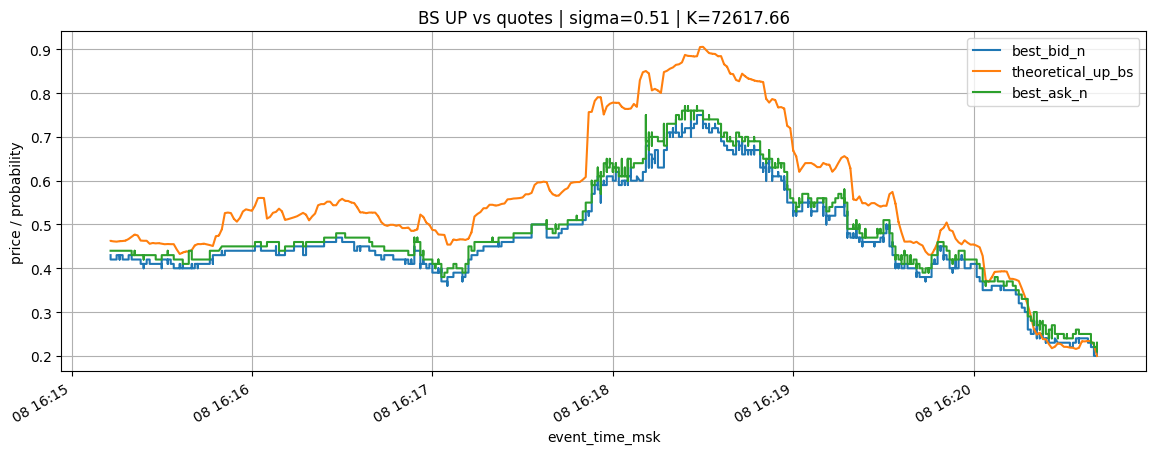

,event_time_msk,best_bid_n,theoretical_up_bs,best_ask_n,spot_value,price_to_beat,buy_edge_bs,sell_edge_bs
109586,2026-04-08 16:20:41,0.21,0.199824,0.23,72486.704432,72617.66,-0.030176,0.010176
109587,2026-04-08 16:20:41,0.21,0.199824,0.23,72486.704432,72617.66,-0.030176,0.010176
109588,2026-04-08 16:20:41,0.21,0.199822,0.23,72486.704432,72617.66,-0.030178,0.010178
109589,2026-04-08 16:20:41,0.21,0.199821,0.23,72486.704432,72617.66,-0.030179,0.010179
109590,2026-04-08 16:20:41,0.21,0.199821,0.23,72486.704432,72617.66,-0.030179,0.010179
109591,2026-04-08 16:20:41,0.21,0.199821,0.23,72486.704432,72617.66,-0.030179,0.010179
109592,2026-04-08 16:20:41,0.21,0.199820,0.23,72486.704432,72617.66,-0.030180,0.010180
109593,2026-04-08 16:20:41,0.21,0.199819,0.23,72486.704432,72617.66,-0.030181,0.010181
109594,2026-04-08 16:20:41,0.21,0.199818,0.23,72486.704432,72617.66,-0.030182,0.010182
109595,2026-04-08 16:20:41,0.21,0.199817,0.23,72486.704432,72617.66,-0.030183,0.010183


In [2]:
import os
import math
import numpy as np
import pandas as pd
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x527ff3f0ffe0ea59a8b9ceda98de92447122d5f16df5482a005272c75f5b3c3f"
sigma = 0.51
r = 0.0
min_total_size = 50.0
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) market_start / market_end / price_to_beat БЕЗ Gamma
# =========================
market_start_ts_ms = int((df_quotes["event_ts_ms"].min() // 900_000) * 900_000)
market_end_ts_ms = market_start_ts_ms + 15 * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {market_start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
price_to_beat_mode = "first_at_or_after_market_start"

if not p2b:
    p2b_sql_fb = f"""
    SELECT event_ts_ms, value
    FROM {DB}.{SPOT_TABLE}
    WHERE symbol = {q(symbol.lower())}
      AND event_ts_ms < {market_start_ts_ms}
    ORDER BY event_ts_ms DESC
    LIMIT 1
    """
    p2b = c.query(p2b_sql_fb).result_rows
    price_to_beat_mode = "last_before_market_start_fallback"

if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT ДЛЯ merge_asof
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {max(0, int(df_quotes['event_ts_ms'].min()) - 120000)}
  AND event_ts_ms <= {max(market_end_ts_ms, int(df_quotes['event_ts_ms'].max()))}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot в выбранном окне")

# =========================
# 4) BLACK-SCHOLES
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bs = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bs["event_time_msk"] = pd.to_datetime(df_bs["event_time_msk"])
df_bs["spot_value"] = df_bs["value"].ffill().bfill()
df_bs["price_to_beat"] = price_to_beat
df_bs["sigma"] = sigma
df_bs["r"] = r
df_bs["market_end_ts_ms"] = market_end_ts_ms
df_bs["time_to_expiry_sec"] = ((df_bs["market_end_ts_ms"] - df_bs["event_ts_ms"]) / 1000.0).clip(lower=0.0)
df_bs["tau_years"] = df_bs["time_to_expiry_sec"] / (365.0 * 24.0 * 60.0 * 60.0)

df_bs["theoretical_up_bs"] = np.where(df_bs["spot_value"] >= price_to_beat, 1.0, 0.0)

mask = (df_bs["tau_years"] > 0) & (df_bs["spot_value"] > 0)
d2 = (
    np.log(df_bs.loc[mask, "spot_value"] / price_to_beat)
    + (r - 0.5 * sigma * sigma) * df_bs.loc[mask, "tau_years"]
) / (sigma * np.sqrt(df_bs.loc[mask, "tau_years"]))

df_bs.loc[mask, "theoretical_up_bs"] = d2.apply(norm_cdf).astype(float)
df_bs["theoretical_up_bs"] = df_bs["theoretical_up_bs"].clip(0.0, 1.0)

df_bs["mid_n"] = (df_bs["best_bid_n"] + df_bs["best_ask_n"]) / 2.0
df_bs["buy_edge_bs"] = df_bs["theoretical_up_bs"] - df_bs["best_ask_n"]
df_bs["sell_edge_bs"] = df_bs["best_bid_n"] - df_bs["theoretical_up_bs"]
df_bs["max_cross_side_edge_bs"] = df_bs[["buy_edge_bs", "sell_edge_bs"]].max(axis=1)
df_bs["inside_spread_bs"] = (
    (df_bs["theoretical_up_bs"] >= df_bs["best_bid_n"])
    & (df_bs["theoretical_up_bs"] <= df_bs["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bs)),
    "sigma": float(sigma),
    "market_start_ts_ms": int(market_start_ts_ms),
    "market_end_ts_ms": int(market_end_ts_ms),
    "price_to_beat": float(price_to_beat),
    "price_to_beat_mode": price_to_beat_mode,
    "inside_spread_rate": float(df_bs["inside_spread_bs"].mean()),
    "mae_to_mid": float((df_bs["theoretical_up_bs"] - df_bs["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bs["theoretical_up_bs"] - df_bs["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bs["theoretical_up_bs"] > df_bs["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bs["theoretical_up_bs"] < df_bs["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bs.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bs", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"BS UP vs quotes | sigma={sigma} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bs[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bs",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bs",
    "sell_edge_bs"
]].tail(30))


,value
rows,154284.000000
price_to_beat,72617.660000
sigma_15m_abs_usd,198.505689
inside_spread_rate,0.077772
mae_to_mid,0.066841
rmse_to_mid,0.083411
pct_theory_above_ask,0.767604
pct_theory_below_bid,0.154624


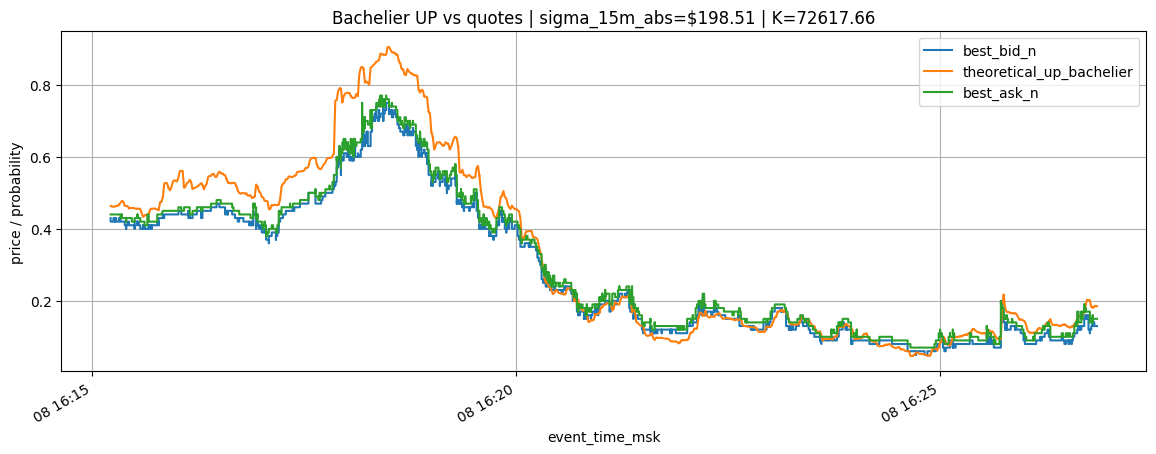

,event_time_msk,best_bid_n,theoretical_up_bachelier,best_ask_n,spot_value,price_to_beat,buy_edge_bach,sell_edge_bach
154254,2026-04-08 16:26:49,0.13,0.183881,0.15,72535.510562,72617.66,0.033881,-0.053881
154255,2026-04-08 16:26:49,0.13,0.183880,0.15,72535.510562,72617.66,0.033880,-0.053880
154256,2026-04-08 16:26:49,0.13,0.183879,0.15,72535.510562,72617.66,0.033879,-0.053879
154257,2026-04-08 16:26:50,0.13,0.185838,0.15,72536.181188,72617.66,0.035838,-0.055838
154258,2026-04-08 16:26:50,0.13,0.185802,0.15,72536.181188,72617.66,0.035802,-0.055802
154259,2026-04-08 16:26:50,0.13,0.185801,0.15,72536.181188,72617.66,0.035801,-0.055801
154260,2026-04-08 16:26:50,0.13,0.185796,0.15,72536.181188,72617.66,0.035796,-0.055796
154261,2026-04-08 16:26:50,0.13,0.185726,0.15,72536.181188,72617.66,0.035726,-0.055726
154262,2026-04-08 16:26:50,0.13,0.185718,0.15,72536.181188,72617.66,0.035718,-0.055718
154263,2026-04-08 16:26:50,0.13,0.185699,0.15,72536.181188,72617.66,0.035699,-0.055699


In [4]:
import os
import math
import numpy as np
import pandas as pd
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x527ff3f0ffe0ea59a8b9ceda98de92447122d5f16df5482a005272c75f5b3c3f"
min_total_size = 50.0
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) ВРЕМЯ РЫНКА И price_to_beat
# =========================
market_start_ts_ms = int((df_quotes["event_ts_ms"].min() // 900_000) * 900_000)
market_end_ts_ms = market_start_ts_ms + 15 * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {market_start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT РЯД
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot")

df_spot["event_time_msk"] = pd.to_datetime(df_spot["event_time_msk"])
df_spot["value"] = df_spot["value"].astype(float)
df_spot = df_spot.drop_duplicates("event_ts_ms").sort_values("event_ts_ms").reset_index(drop=True)

# =========================
# 4) НОРМАЛЬНАЯ ВОЛА В ДОЛЛАРАХ
# =========================
s_1m = df_spot.set_index("event_time_msk")["value"].resample("1min").last().ffill().dropna()
d15 = s_1m.diff(15).dropna()

if len(d15) < 10:
    raise ValueError("Слишком мало данных для оценки нормальной 15m-волы")

sigma_15m_abs = float(d15.std(ddof=1))

# =========================
# 5) BACHELIER MODEL
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bach = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bach["event_time_msk"] = pd.to_datetime(df_bach["event_time_msk"])
df_bach["spot_value"] = df_bach["value"].ffill().bfill()
df_bach["price_to_beat"] = price_to_beat
df_bach["market_end_ts_ms"] = market_end_ts_ms
df_bach["time_to_expiry_sec"] = ((df_bach["market_end_ts_ms"] - df_bach["event_ts_ms"]) / 1000.0).clip(lower=0.0)

# Нормальная модель: S_T ~ N(S_t, sigma_abs^2 * tau/15m)
tau_scale = df_bach["time_to_expiry_sec"] / (15 * 60.0)
sigma_t_abs = sigma_15m_abs * np.sqrt(tau_scale.clip(lower=0.0))

z = (df_bach["spot_value"] - df_bach["price_to_beat"]) / sigma_t_abs.replace(0, np.nan)
df_bach["theoretical_up_bachelier"] = z.apply(lambda x: norm_cdf(x) if pd.notna(x) else np.nan)
df_bach["theoretical_up_bachelier"] = np.where(
    df_bach["time_to_expiry_sec"] <= 0,
    (df_bach["spot_value"] >= df_bach["price_to_beat"]).astype(float),
    df_bach["theoretical_up_bachelier"]
)
df_bach["theoretical_up_bachelier"] = pd.Series(df_bach["theoretical_up_bachelier"]).clip(0.0, 1.0)

df_bach["mid_n"] = (df_bach["best_bid_n"] + df_bach["best_ask_n"]) / 2.0
df_bach["buy_edge_bach"] = df_bach["theoretical_up_bachelier"] - df_bach["best_ask_n"]
df_bach["sell_edge_bach"] = df_bach["best_bid_n"] - df_bach["theoretical_up_bachelier"]
df_bach["inside_spread_bach"] = (
    (df_bach["theoretical_up_bachelier"] >= df_bach["best_bid_n"])
    & (df_bach["theoretical_up_bachelier"] <= df_bach["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bach)),
    "price_to_beat": float(price_to_beat),
    "sigma_15m_abs_usd": float(sigma_15m_abs),
    "inside_spread_rate": float(df_bach["inside_spread_bach"].mean()),
    "mae_to_mid": float((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bach["theoretical_up_bachelier"] > df_bach["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bach["theoretical_up_bachelier"] < df_bach["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bach.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bachelier", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Bachelier UP vs quotes | sigma_15m_abs=${sigma_15m_abs:.2f} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bach[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bachelier",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bach",
    "sell_edge_bach"
]].tail(30))


,value
rows,96793.000000
price_to_beat,71630.920000
sigma_15m_abs_usd,198.499821
inside_spread_rate,0.087796
mae_to_mid,0.077334
rmse_to_mid,0.097758
pct_theory_above_ask,0.495831
pct_theory_below_bid,0.410743


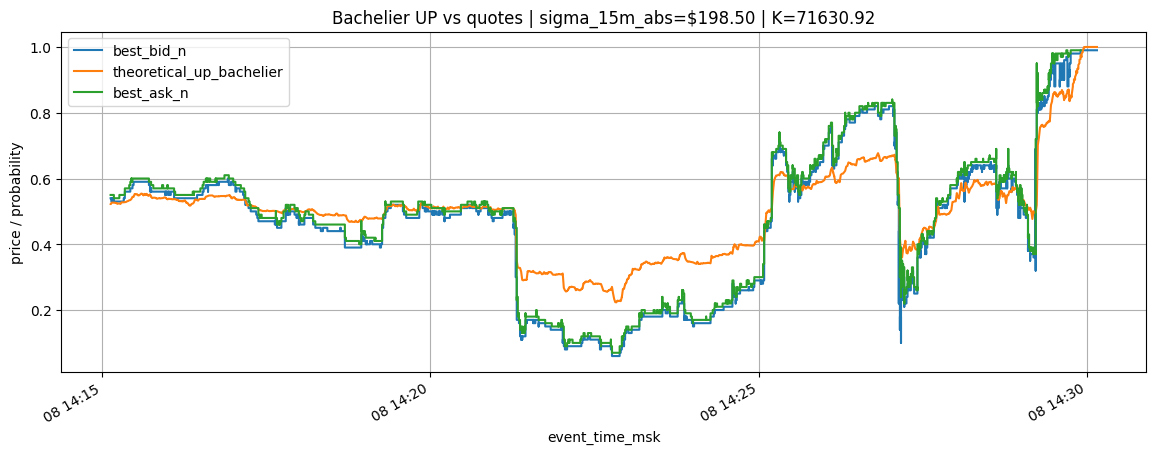

,event_time_msk,best_bid_n,theoretical_up_bachelier,best_ask_n,spot_value,price_to_beat,buy_edge_bach,sell_edge_bach
96763,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96764,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96765,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96766,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96767,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96768,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96769,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96770,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96771,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01
96772,2026-04-08 14:30:04,0.99,1.0,NaN,71659.978419,71630.92,NaN,-0.01


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x93ecde85f53892c69cc75a8755a86983f1240e919d59ad37cfbbc724875c75bb"
min_total_size = 50.0
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) ВРЕМЯ РЫНКА И price_to_beat
# =========================
market_start_ts_ms = int((df_quotes["event_ts_ms"].min() // 900_000) * 900_000)
market_end_ts_ms = market_start_ts_ms + 15 * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {market_start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT РЯД
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot")

df_spot["event_time_msk"] = pd.to_datetime(df_spot["event_time_msk"])
df_spot["value"] = df_spot["value"].astype(float)
df_spot = df_spot.drop_duplicates("event_ts_ms").sort_values("event_ts_ms").reset_index(drop=True)

# =========================
# 4) НОРМАЛЬНАЯ ВОЛА В ДОЛЛАРАХ
# =========================
s_1m = df_spot.set_index("event_time_msk")["value"].resample("1min").last().ffill().dropna()
d15 = s_1m.diff(15).dropna()

if len(d15) < 10:
    raise ValueError("Слишком мало данных для оценки нормальной 15m-волы")

sigma_15m_abs = float(d15.std(ddof=1))

# =========================
# 5) BACHELIER MODEL
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bach = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bach["event_time_msk"] = pd.to_datetime(df_bach["event_time_msk"])
df_bach["spot_value"] = df_bach["value"].ffill().bfill()
df_bach["price_to_beat"] = price_to_beat
df_bach["market_end_ts_ms"] = market_end_ts_ms
df_bach["time_to_expiry_sec"] = ((df_bach["market_end_ts_ms"] - df_bach["event_ts_ms"]) / 1000.0).clip(lower=0.0)

# Нормальная модель: S_T ~ N(S_t, sigma_abs^2 * tau/15m)
tau_scale = df_bach["time_to_expiry_sec"] / (15 * 60.0)
sigma_t_abs = sigma_15m_abs * np.sqrt(tau_scale.clip(lower=0.0))

z = (df_bach["spot_value"] - df_bach["price_to_beat"]) / sigma_t_abs.replace(0, np.nan)
df_bach["theoretical_up_bachelier"] = z.apply(lambda x: norm_cdf(x) if pd.notna(x) else np.nan)
df_bach["theoretical_up_bachelier"] = np.where(
    df_bach["time_to_expiry_sec"] <= 0,
    (df_bach["spot_value"] >= df_bach["price_to_beat"]).astype(float),
    df_bach["theoretical_up_bachelier"]
)
df_bach["theoretical_up_bachelier"] = pd.Series(df_bach["theoretical_up_bachelier"]).clip(0.0, 1.0)

df_bach["mid_n"] = (df_bach["best_bid_n"] + df_bach["best_ask_n"]) / 2.0
df_bach["buy_edge_bach"] = df_bach["theoretical_up_bachelier"] - df_bach["best_ask_n"]
df_bach["sell_edge_bach"] = df_bach["best_bid_n"] - df_bach["theoretical_up_bachelier"]
df_bach["inside_spread_bach"] = (
    (df_bach["theoretical_up_bachelier"] >= df_bach["best_bid_n"])
    & (df_bach["theoretical_up_bachelier"] <= df_bach["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bach)),
    "price_to_beat": float(price_to_beat),
    "sigma_15m_abs_usd": float(sigma_15m_abs),
    "inside_spread_rate": float(df_bach["inside_spread_bach"].mean()),
    "mae_to_mid": float((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bach["theoretical_up_bachelier"] > df_bach["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bach["theoretical_up_bachelier"] < df_bach["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bach.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bachelier", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Bachelier UP vs quotes | sigma_15m_abs=${sigma_15m_abs:.2f} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bach[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bachelier",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bach",
    "sell_edge_bach"
]].tail(30))


,value
rows,104584.000000
price_to_beat,71938.804496
sigma_15m_abs_usd,198.853108
inside_spread_rate,0.063652
mae_to_mid,0.061710
rmse_to_mid,0.075439
pct_theory_above_ask,0.345330
pct_theory_below_bid,0.574390


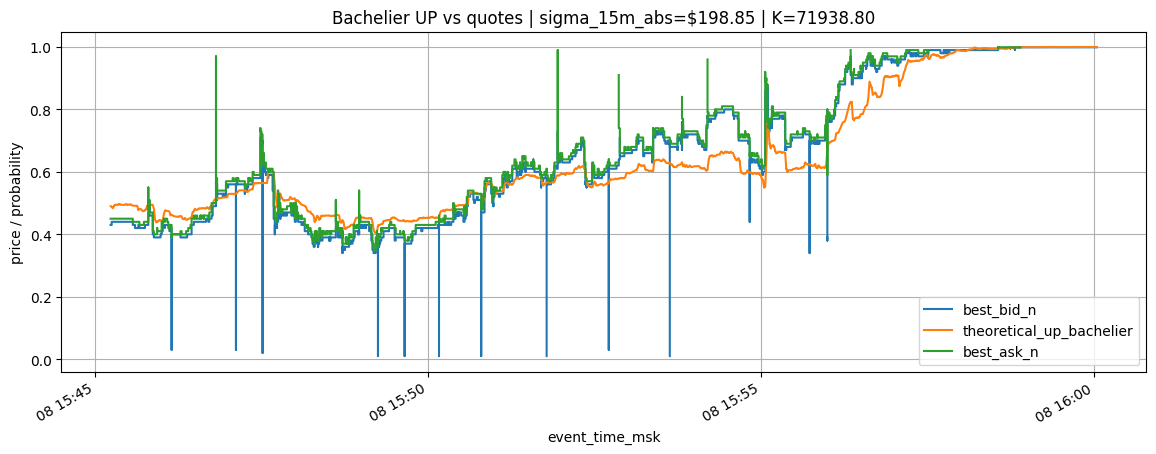

,event_time_msk,best_bid_n,theoretical_up_bachelier,best_ask_n,spot_value,price_to_beat,buy_edge_bach,sell_edge_bach
104554,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104555,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104556,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104557,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104558,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104559,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104560,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104561,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104562,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001
104563,2026-04-08 16:00:02,0.999,1.0,NaN,72075.881735,71938.804496,NaN,-0.001


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x527ff3f0ffe0ea59a8b9ceda98de92447122d5f16df5482a005272c75f5b3c3f"
min_total_size = 50.0
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) ВРЕМЯ РЫНКА И price_to_beat
# =========================
market_start_ts_ms = int((df_quotes["event_ts_ms"].min() // 900_000) * 900_000)
market_end_ts_ms = market_start_ts_ms + 15 * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {market_start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT РЯД
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot")

df_spot["event_time_msk"] = pd.to_datetime(df_spot["event_time_msk"])
df_spot["value"] = df_spot["value"].astype(float)
df_spot = df_spot.drop_duplicates("event_ts_ms").sort_values("event_ts_ms").reset_index(drop=True)

# =========================
# 4) НОРМАЛЬНАЯ ВОЛА В ДОЛЛАРАХ
# =========================
s_1m = df_spot.set_index("event_time_msk")["value"].resample("1min").last().ffill().dropna()
d15 = s_1m.diff(15).dropna()

if len(d15) < 10:
    raise ValueError("Слишком мало данных для оценки нормальной 15m-волы")

sigma_15m_abs = float(d15.std(ddof=1))

# =========================
# 5) BACHELIER MODEL
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bach = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bach["event_time_msk"] = pd.to_datetime(df_bach["event_time_msk"])
df_bach["spot_value"] = df_bach["value"].ffill().bfill()
df_bach["price_to_beat"] = price_to_beat
df_bach["market_end_ts_ms"] = market_end_ts_ms
df_bach["time_to_expiry_sec"] = ((df_bach["market_end_ts_ms"] - df_bach["event_ts_ms"]) / 1000.0).clip(lower=0.0)

# Нормальная модель: S_T ~ N(S_t, sigma_abs^2 * tau/15m)
tau_scale = df_bach["time_to_expiry_sec"] / (15 * 60.0)
sigma_t_abs = sigma_15m_abs * np.sqrt(tau_scale.clip(lower=0.0))

z = (df_bach["spot_value"] - df_bach["price_to_beat"]) / sigma_t_abs.replace(0, np.nan)
df_bach["theoretical_up_bachelier"] = z.apply(lambda x: norm_cdf(x) if pd.notna(x) else np.nan)
df_bach["theoretical_up_bachelier"] = np.where(
    df_bach["time_to_expiry_sec"] <= 0,
    (df_bach["spot_value"] >= df_bach["price_to_beat"]).astype(float),
    df_bach["theoretical_up_bachelier"]
)
df_bach["theoretical_up_bachelier"] = pd.Series(df_bach["theoretical_up_bachelier"]).clip(0.0, 1.0)

df_bach["mid_n"] = (df_bach["best_bid_n"] + df_bach["best_ask_n"]) / 2.0
df_bach["buy_edge_bach"] = df_bach["theoretical_up_bachelier"] - df_bach["best_ask_n"]
df_bach["sell_edge_bach"] = df_bach["best_bid_n"] - df_bach["theoretical_up_bachelier"]
df_bach["inside_spread_bach"] = (
    (df_bach["theoretical_up_bachelier"] >= df_bach["best_bid_n"])
    & (df_bach["theoretical_up_bachelier"] <= df_bach["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bach)),
    "price_to_beat": float(price_to_beat),
    "sigma_15m_abs_usd": float(sigma_15m_abs),
    "inside_spread_rate": float(df_bach["inside_spread_bach"].mean()),
    "mae_to_mid": float((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bach["theoretical_up_bachelier"] > df_bach["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bach["theoretical_up_bachelier"] < df_bach["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bach.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bachelier", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Bachelier UP vs quotes | sigma_15m_abs=${sigma_15m_abs:.2f} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bach[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bachelier",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bach",
    "sell_edge_bach"
]].tail(30))


In [7]:
import os
import pandas as pd
import clickhouse_connect
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env", override=True)

db = os.getenv("CLICKHOUSE_DB", "polyk")
orderbook_table = os.getenv("ORDERBOOK_TABLE", "orderbook")
pricechange_table = os.getenv("PRICECHANGE_TABLE", "pricechange")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=db,
)

sql = f"""
SELECT
    market,
    min(event_time_msk) AS first_time_msk,
    max(event_time_msk) AS last_time_msk,
    count() AS rows_cnt
FROM
(
    SELECT market, event_time_msk FROM {db}.{orderbook_table}
    UNION ALL
    SELECT market, event_time_msk FROM {db}.{pricechange_table}
)
GROUP BY market
ORDER BY first_time_msk DESC
"""

res = c.query(sql)
df_markets = pd.DataFrame(res.result_rows, columns=res.column_names)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_columns", None)

display(df_markets)


,market,first_time_msk,last_time_msk,rows_cnt
0,0xf402846bced8b46e6c2104689ad485fe12b65495cf7efc4d94fbf82c79158584,2026-04-08 16:30:14,2026-04-08 16:33:42,53381
1,0x527ff3f0ffe0ea59a8b9ceda98de92447122d5f16df5482a005272c75f5b3c3f,2026-04-08 16:15:13,2026-04-08 16:30:05,197898
2,0x409d039650387605abcecfcc2e76ab5d3d524280b968cb799c05c20549795704,2026-04-08 16:00:11,2026-04-08 16:15:09,115079
3,0x93ecde85f53892c69cc75a8755a86983f1240e919d59ad37cfbbc724875c75bb,2026-04-08 15:45:14,2026-04-08 16:00:03,133765
4,0x013640a218e2007a6a4dbfded785df40361fcb0392fefcc4c19ffac1405015cb,2026-04-08 15:30:07,2026-04-08 15:45:06,91357
...,...,...,...,...
102,0xaa459ad788b034cd2f65add71feccba6ffbd989cfbb3ce387944ecb558005051,2026-04-07 15:00:08,2026-04-07 15:15:03,139076
103,0x3c4d9cb221319f503f428e4972ade7063542cb0a7ad4670de1609778a23c0e7a,2026-04-07 14:45:08,2026-04-07 15:00:00,108285
104,0xb3998ae4f73513ea3bc588066179c78ad59a1b870c4adc6a322960bde1a2ca3e,2026-04-07 14:30:06,2026-04-07 14:45:00,157741
105,0x4d9e7ba812a66821a2d70e40fb92c4db21805e7431a5f1dd52f4a4c3ba7d90d3,2026-04-07 14:15:08,2026-04-07 14:29:59,164642


,value
rows,165733.000000
price_to_beat,72617.660000
sigma_15m_abs_usd,200.423158
inside_spread_rate,0.077993
mae_to_mid,0.065234
rmse_to_mid,0.081154
pct_theory_above_ask,0.783356
pct_theory_below_bid,0.131326


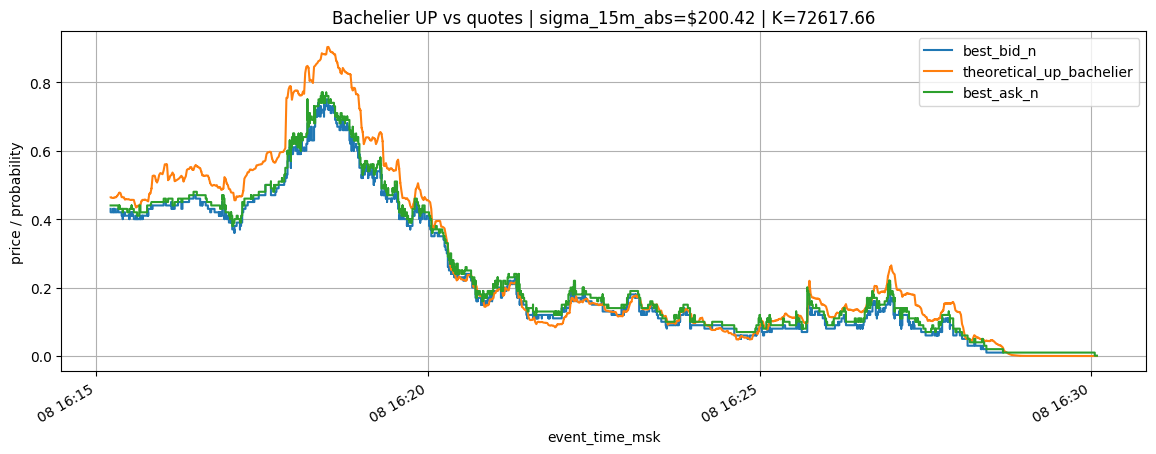

,event_time_msk,best_bid_n,theoretical_up_bachelier,best_ask_n,spot_value,price_to_beat,buy_edge_bach,sell_edge_bach
165703,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165704,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165705,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165706,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165707,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165708,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165709,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165710,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165711,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN
165712,2026-04-08 16:30:04,NaN,0.0,0.001,72588.303634,72617.66,-0.001,NaN


In [8]:
import os
import math
import numpy as np
import pandas as pd
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x527ff3f0ffe0ea59a8b9ceda98de92447122d5f16df5482a005272c75f5b3c3f"
min_total_size = 50.0
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) ВРЕМЯ РЫНКА И price_to_beat
# =========================
market_start_ts_ms = int((df_quotes["event_ts_ms"].min() // 900_000) * 900_000)
market_end_ts_ms = market_start_ts_ms + 15 * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {market_start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT РЯД
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot")

df_spot["event_time_msk"] = pd.to_datetime(df_spot["event_time_msk"])
df_spot["value"] = df_spot["value"].astype(float)
df_spot = df_spot.drop_duplicates("event_ts_ms").sort_values("event_ts_ms").reset_index(drop=True)

# =========================
# 4) НОРМАЛЬНАЯ ВОЛА В ДОЛЛАРАХ
# =========================
s_1m = df_spot.set_index("event_time_msk")["value"].resample("1min").last().ffill().dropna()
d15 = s_1m.diff(15).dropna()

if len(d15) < 10:
    raise ValueError("Слишком мало данных для оценки нормальной 15m-волы")

sigma_15m_abs = float(d15.std(ddof=1))

# =========================
# 5) BACHELIER MODEL
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bach = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bach["event_time_msk"] = pd.to_datetime(df_bach["event_time_msk"])
df_bach["spot_value"] = df_bach["value"].ffill().bfill()
df_bach["price_to_beat"] = price_to_beat
df_bach["market_end_ts_ms"] = market_end_ts_ms
df_bach["time_to_expiry_sec"] = ((df_bach["market_end_ts_ms"] - df_bach["event_ts_ms"]) / 1000.0).clip(lower=0.0)

# Нормальная модель: S_T ~ N(S_t, sigma_abs^2 * tau/15m)
tau_scale = df_bach["time_to_expiry_sec"] / (15 * 60.0)
sigma_t_abs = sigma_15m_abs * np.sqrt(tau_scale.clip(lower=0.0))

z = (df_bach["spot_value"] - df_bach["price_to_beat"]) / sigma_t_abs.replace(0, np.nan)
df_bach["theoretical_up_bachelier"] = z.apply(lambda x: norm_cdf(x) if pd.notna(x) else np.nan)
df_bach["theoretical_up_bachelier"] = np.where(
    df_bach["time_to_expiry_sec"] <= 0,
    (df_bach["spot_value"] >= df_bach["price_to_beat"]).astype(float),
    df_bach["theoretical_up_bachelier"]
)
df_bach["theoretical_up_bachelier"] = pd.Series(df_bach["theoretical_up_bachelier"]).clip(0.0, 1.0)

df_bach["mid_n"] = (df_bach["best_bid_n"] + df_bach["best_ask_n"]) / 2.0
df_bach["buy_edge_bach"] = df_bach["theoretical_up_bachelier"] - df_bach["best_ask_n"]
df_bach["sell_edge_bach"] = df_bach["best_bid_n"] - df_bach["theoretical_up_bachelier"]
df_bach["inside_spread_bach"] = (
    (df_bach["theoretical_up_bachelier"] >= df_bach["best_bid_n"])
    & (df_bach["theoretical_up_bachelier"] <= df_bach["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bach)),
    "price_to_beat": float(price_to_beat),
    "sigma_15m_abs_usd": float(sigma_15m_abs),
    "inside_spread_rate": float(df_bach["inside_spread_bach"].mean()),
    "mae_to_mid": float((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bach["theoretical_up_bachelier"] > df_bach["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bach["theoretical_up_bachelier"] < df_bach["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bach.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bachelier", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Bachelier UP vs quotes | sigma_15m_abs=${sigma_15m_abs:.2f} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bach[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bachelier",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bach",
    "sell_edge_bach"
]].tail(30))


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import clickhouse_connect
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display

# =========================
# ПАРАМЕТРЫ
# =========================
market = "0x3c4d9cb221319f503f428e4972ade7063542cb0a7ad4670de1609778a23c0e7a"
min_total_size = 50.0
symbol = "btc/usd"

# =========================
# ПОДКЛЮЧЕНИЕ
# =========================
load_dotenv(".env", override=True)

DB = os.getenv("CLICKHOUSE_DB", "polyk")
ORDERBOOK_TABLE = os.getenv("ORDERBOOK_TABLE", "orderbook")
PRICECHANGE_TABLE = os.getenv("PRICECHANGE_TABLE", "pricechange")
SPOT_TABLE = os.getenv("SPOT_TABLE", "btc_spot")

c = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER"),
    password=os.getenv("CLICKHOUSE_PASSWORD"),
    database=DB,
)

def q(v: str) -> str:
    return "'" + str(v).replace("'", "''") + "'"

def depth_price(level_sizes: dict, ordered_prices: list, n: float):
    total = 0.0
    for p in ordered_prices:
        s = float(level_sizes.get(p, 0.0) or 0.0)
        if s <= 0:
            continue
        total += s
        if total + 1e-12 >= float(n):
            return float(p), float(total)
    return float("nan"), float(total)

def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# =========================
# 1) ВОССТАНОВЛЕНИЕ best_bid_n / best_ask_n
# =========================
meta_sql = f"""
SELECT
    market,
    asset_id,
    hash,
    max(event_ts_ms) AS snapshot_ts_ms,
    max(event_time_msk) AS snapshot_time_msk
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
GROUP BY market, asset_id, hash
ORDER BY snapshot_ts_ms DESC
LIMIT 1
"""
meta_res = c.query(meta_sql)
if not meta_res.result_rows:
    raise ValueError("Не найден snapshot для этого market в orderbook")

meta = dict(zip(meta_res.column_names, meta_res.result_rows[0]))
asset_id = str(meta["asset_id"])
ob_hash = str(meta["hash"])
snapshot_ts_ms = int(meta["snapshot_ts_ms"])
snapshot_time_msk = meta["snapshot_time_msk"]

snap_sql = f"""
SELECT side, price, size
FROM {DB}.{ORDERBOOK_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND hash = {q(ob_hash)}
ORDER BY price ASC
"""
snap_res = c.query(snap_sql)
df_snap = pd.DataFrame(snap_res.result_rows, columns=snap_res.column_names)
if df_snap.empty:
    raise ValueError("Пустой snapshot")

price_grid = sorted(float(x) for x in df_snap["price"].tolist())
bid_prices_desc = list(reversed(price_grid))
ask_prices_asc = price_grid[:]

bid_sizes = {p: 0.0 for p in price_grid}
ask_sizes = {p: 0.0 for p in price_grid}

for row in df_snap.itertuples(index=False):
    p = float(row.price)
    s = float(row.size)
    if row.side == "bid":
        bid_sizes[p] = s
    elif row.side == "ask":
        ask_sizes[p] = s

records = []

bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
records.append({
    "event_time_msk": snapshot_time_msk,
    "event_ts_ms": snapshot_ts_ms,
    "best_bid_n": bb,
    "best_ask_n": ba,
})

pc_sql = f"""
SELECT event_time_msk, event_ts_ms, side, price, size
FROM {DB}.{PRICECHANGE_TABLE}
WHERE market = {q(market)}
  AND asset_id = {q(asset_id)}
  AND event_ts_ms >= {snapshot_ts_ms}
ORDER BY event_ts_ms ASC, price ASC
"""
pc_res = c.query(pc_sql)
df_pc = pd.DataFrame(pc_res.result_rows, columns=pc_res.column_names)

if not df_pc.empty:
    current_ts = None
    current_time = None

    for row in df_pc.itertuples(index=False):
        row_ts = int(row.event_ts_ms)

        if current_ts is None:
            current_ts = row_ts
            current_time = row.event_time_msk
        elif row_ts != current_ts:
            bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
            ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
            records.append({
                "event_time_msk": current_time,
                "event_ts_ms": current_ts,
                "best_bid_n": bb,
                "best_ask_n": ba,
            })
            current_ts = row_ts
            current_time = row.event_time_msk

        p = float(row.price)
        ds = float(row.size)

        if row.side == "bid":
            ns = bid_sizes.get(p, 0.0) + ds
            bid_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns
        elif row.side == "ask":
            ns = ask_sizes.get(p, 0.0) + ds
            ask_sizes[p] = 0.0 if abs(ns) <= 1e-12 else ns

    if current_ts is not None:
        bb, cb = depth_price(bid_sizes, bid_prices_desc, min_total_size)
        ba, ca = depth_price(ask_sizes, ask_prices_asc, min_total_size)
        records.append({
            "event_time_msk": current_time,
            "event_ts_ms": current_ts,
            "best_bid_n": bb,
            "best_ask_n": ba,
        })

df_quotes = pd.DataFrame(records).sort_values("event_ts_ms").reset_index(drop=True)
if df_quotes.empty:
    raise ValueError("df_quotes пустой")

# =========================
# 2) ВРЕМЯ РЫНКА И price_to_beat
# =========================
market_start_ts_ms = int((df_quotes["event_ts_ms"].min() // 900_000) * 900_000)
market_end_ts_ms = market_start_ts_ms + 15 * 60 * 1000

p2b_sql = f"""
SELECT event_ts_ms, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
  AND event_ts_ms >= {market_start_ts_ms}
ORDER BY event_ts_ms ASC
LIMIT 1
"""
p2b = c.query(p2b_sql).result_rows
if not p2b:
    raise ValueError("Не найден price_to_beat в btc_spot")

price_to_beat = float(p2b[0][1])

# =========================
# 3) SPOT РЯД
# =========================
spot_sql = f"""
SELECT event_ts_ms, event_time_msk, value
FROM {DB}.{SPOT_TABLE}
WHERE symbol = {q(symbol.lower())}
ORDER BY event_ts_ms ASC
"""
spot_res = c.query(spot_sql)
df_spot = pd.DataFrame(spot_res.result_rows, columns=spot_res.column_names)
if df_spot.empty:
    raise ValueError("Пустой df_spot")

df_spot["event_time_msk"] = pd.to_datetime(df_spot["event_time_msk"])
df_spot["value"] = df_spot["value"].astype(float)
df_spot = df_spot.drop_duplicates("event_ts_ms").sort_values("event_ts_ms").reset_index(drop=True)

# =========================
# 4) НОРМАЛЬНАЯ ВОЛА В ДОЛЛАРАХ
# =========================
s_1m = df_spot.set_index("event_time_msk")["value"].resample("1min").last().ffill().dropna()
d15 = s_1m.diff(15).dropna()

if len(d15) < 10:
    raise ValueError("Слишком мало данных для оценки нормальной 15m-волы")

sigma_15m_abs = float(d15.std(ddof=1))

# =========================
# 5) BACHELIER MODEL
# =========================
df_q = df_quotes.sort_values("event_ts_ms").reset_index(drop=True).copy()
df_s = df_spot.sort_values("event_ts_ms").reset_index(drop=True).copy()

df_bach = pd.merge_asof(
    df_q,
    df_s[["event_ts_ms", "value"]],
    on="event_ts_ms",
    direction="backward"
)

df_bach["event_time_msk"] = pd.to_datetime(df_bach["event_time_msk"])
df_bach["spot_value"] = df_bach["value"].ffill().bfill()
df_bach["price_to_beat"] = price_to_beat
df_bach["market_end_ts_ms"] = market_end_ts_ms
df_bach["time_to_expiry_sec"] = ((df_bach["market_end_ts_ms"] - df_bach["event_ts_ms"]) / 1000.0).clip(lower=0.0)

# Нормальная модель: S_T ~ N(S_t, sigma_abs^2 * tau/15m)
tau_scale = df_bach["time_to_expiry_sec"] / (15 * 60.0)
sigma_t_abs = sigma_15m_abs * np.sqrt(tau_scale.clip(lower=0.0))

z = (df_bach["spot_value"] - df_bach["price_to_beat"]) / sigma_t_abs.replace(0, np.nan)
df_bach["theoretical_up_bachelier"] = z.apply(lambda x: norm_cdf(x) if pd.notna(x) else np.nan)
df_bach["theoretical_up_bachelier"] = np.where(
    df_bach["time_to_expiry_sec"] <= 0,
    (df_bach["spot_value"] >= df_bach["price_to_beat"]).astype(float),
    df_bach["theoretical_up_bachelier"]
)
df_bach["theoretical_up_bachelier"] = pd.Series(df_bach["theoretical_up_bachelier"]).clip(0.0, 1.0)

df_bach["mid_n"] = (df_bach["best_bid_n"] + df_bach["best_ask_n"]) / 2.0
df_bach["buy_edge_bach"] = df_bach["theoretical_up_bachelier"] - df_bach["best_ask_n"]
df_bach["sell_edge_bach"] = df_bach["best_bid_n"] - df_bach["theoretical_up_bachelier"]
df_bach["inside_spread_bach"] = (
    (df_bach["theoretical_up_bachelier"] >= df_bach["best_bid_n"])
    & (df_bach["theoretical_up_bachelier"] <= df_bach["best_ask_n"])
).astype(int)

metrics = {
    "rows": int(len(df_bach)),
    "price_to_beat": float(price_to_beat),
    "sigma_15m_abs_usd": float(sigma_15m_abs),
    "inside_spread_rate": float(df_bach["inside_spread_bach"].mean()),
    "mae_to_mid": float((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]).abs().mean()),
    "rmse_to_mid": float(np.sqrt(((df_bach["theoretical_up_bachelier"] - df_bach["mid_n"]) ** 2).mean())),
    "pct_theory_above_ask": float((df_bach["theoretical_up_bachelier"] > df_bach["best_ask_n"]).mean()),
    "pct_theory_below_bid": float((df_bach["theoretical_up_bachelier"] < df_bach["best_bid_n"]).mean()),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))

ax = df_bach.plot(
    x="event_time_msk",
    y=["best_bid_n", "theoretical_up_bachelier", "best_ask_n"],
    figsize=(14, 5),
    grid=True,
    title=f"Bachelier UP vs quotes | sigma_15m_abs=${sigma_15m_abs:.2f} | K={price_to_beat:.2f}",
)
ax.set_ylabel("price / probability")
plt.show()

display(df_bach[[
    "event_time_msk",
    "best_bid_n",
    "theoretical_up_bachelier",
    "best_ask_n",
    "spot_value",
    "price_to_beat",
    "buy_edge_bach",
    "sell_edge_bach"
]].tail(30))
